Binary classification **can** be applied to stock price prediction, but it's typically used for **different tasks** than continuous price prediction. Here’s how binary classification fits into the stock market context:

### **When Binary Classification is Used for Stock Prices:**

1. **Price Direction Prediction**:
   Instead of predicting the exact future price, you may want to predict whether the price will **go up or down**. In this case, binary classification is highly relevant. The output could be:
   - `1` for price going up (e.g., tomorrow's closing price > today's closing price)
   - `0` for price going down (e.g., tomorrow's closing price <= today's closing price)

   Example task:
   - **Classification goal**: Will the stock price rise or fall tomorrow?
   - **Metrics**: Accuracy, precision, recall, F1 score, AUC-ROC.

   In this case, you don’t need a threshold because the output is naturally binary (up or down).

2. **Threshold-Based Event Prediction**:
   You may define a threshold where you’re interested in predicting whether the price will exceed a certain level or percentage increase, instead of focusing on the exact value.
   - For example, predict whether the stock price will increase by **more than 2%** in the next week.
   - `1` if the price increase exceeds 2%, `0` otherwise.

   Example task:
   - **Classification goal**: Will the stock price rise by more than 2% in the next 5 days?
   - **Metrics**: Precision, recall, F1 score, etc.

### **When Regression (Continuous Prediction) is Used:**

1. **Exact Price Prediction**:
   When your goal is to predict the **exact closing price** at a future point (e.g., tomorrow's price, next month's price), this is a regression problem. Here, you would use continuous prediction models (like ARIMA, SARIMA, or deep learning models) and evaluate using regression metrics like MAE, MSE, RMSE, etc.

### **How to Decide Between Binary Classification and Regression**:

- **Use binary classification** if your goal is to predict **events** like whether the price will go up or down, or whether a specific threshold will be breached (e.g., stock rising above a certain level).
- **Use regression** if your goal is to predict **exact values**, such as the closing price at a specific date.

### Summary:

- **Binary classification** is suitable when the problem is reframed to focus on the **direction** or a specific **threshold** (e.g., price rise/fall or significant change).
- **Regression** is used when predicting the **actual price** itself.

So, binary classification is not generally used for exact stock price prediction but is often used for **trend prediction** (up or down) or **threshold-based predictions**.

# **ARIMA**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Validation MAE: 15063.520457548926
Validation MSE: 356002889.5078483
Validation RMSE: 18868.03883576267
Validation MAPE: 21.895398084192387%
Validation Accuracy: 0.366120218579235
Validation Precision: 0.5
Validation Recall: 0.0603448275862069
Validation F1-score: 0.1076923076923077
Validation AUC-ROC: 0.5174022130725683


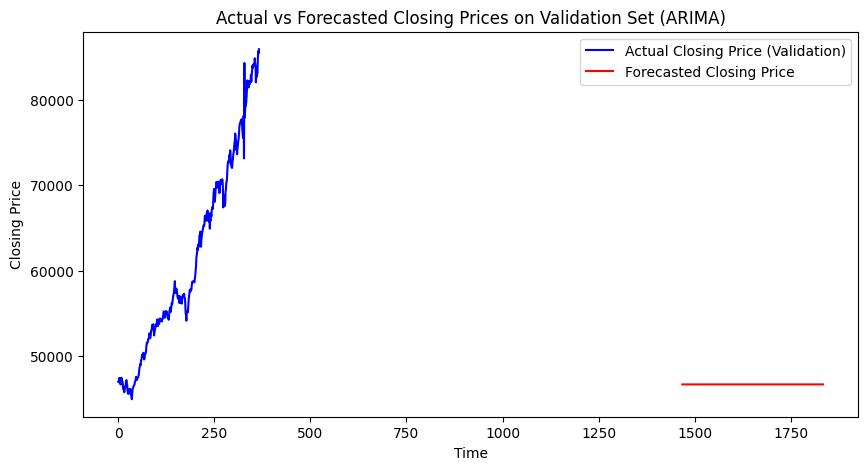

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Load the dataset (Training.csv)
train_data = pd.read_csv('Training.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

# Drop NaN values
train_data = train_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Split data into 80% training and 20% validation
train_size = int(len(train_data) * 0.8)
train_set, validation_set = train_data[:train_size], train_data[train_size:]

# Fit ARIMA model on the training set using the 'Close' column as the target variable
p, d, q = 1, 1, 1  # ARIMA parameters (p, d, q)
arima_model = ARIMA(train_set['Close'], order=(p, d, q))
arima_model_fit = arima_model.fit()

# Forecast the closing prices for the validation set
forecast_steps = len(validation_set)  # Number of steps to forecast
forecast = arima_model_fit.forecast(steps=forecast_steps)

# Calculate regression evaluation metrics on the validation set
mae = mean_absolute_error(validation_set['Close'], forecast)
mse = mean_squared_error(validation_set['Close'], forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(validation_set['Close'], forecast)

# Print regression evaluation metrics for the validation set
print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation RMSE: {rmse}")
print(f"Validation MAPE: {mape * 100}%")

# Define binary classification based on price increase (Price will go up or down)
true_binary = np.where(validation_set['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary = np.where(np.array(forecast) - validation_set['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary[:-1], pred_binary[:-1])  # Exclude the last element due to shift
precision = precision_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
recall = recall_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
f1 = f1_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
auc_roc = roc_auc_score(true_binary[:-1], forecast[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the validation set
print(f"Validation Accuracy: {accuracy}")
print(f"Validation Precision: {precision}")
print(f"Validation Recall: {recall}")
print(f"Validation F1-score: {f1}")
print(f"Validation AUC-ROC: {auc_roc}")

# Plot actual vs forecasted values for the validation set
plt.figure(figsize=(10, 5))
plt.plot(validation_set['Close'].values, label='Actual Closing Price (Validation)', color='blue')
plt.plot(forecast, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Validation Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()


with shift and threshold

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Validation Metrics:
Validation MAE: 16755.958893749237
Validation MSE: 433979077.25898165
Validation RMSE: 20832.164488093447
Validation MAPE: 24.42038668869291%
Validation Accuracy: 0.36065573770491804
Validation Precision: 0.45454545454545453
Validation Recall: 0.04310344827586207
Validation F1-score: 0.07874015748031496
Validation AUC-ROC: 0.49845599588265566

Test Metrics:
Test MAE: 39422.671501441175
Test MSE: 1558441610.7515574
Test RMSE: 39477.102360122095
Test MAPE: 45.898112577995306%
Test Accuracy: 0.5084745762711864
Test Precision: 0.0
Test Recall: 0.0
Test F1-score: 0.0
Test AUC-ROC: 0.5321839080459769


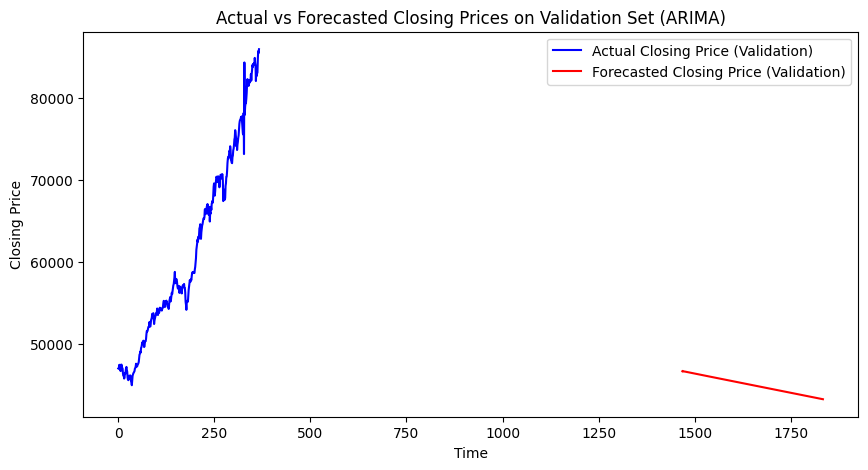

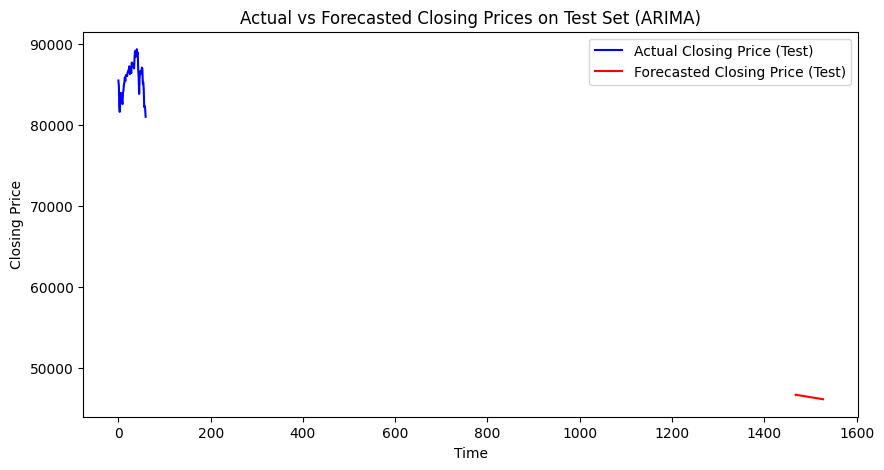

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')
    test_data[col] = pd.to_numeric(test_data[col], errors='coerce')

# Drop NaN values in both datasets
train_data = train_data.dropna(subset=['Close', 'Open', 'High', 'Low'])
test_data = test_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Split the train_data into 80% training and 20% validation
train_size = int(len(train_data) * 0.8)
train_set, validation_set = train_data[:train_size], train_data[train_size:]

# Fit ARIMA model on the training set using the 'Close' column as the target variable
p, d, q = 5,2,0  # ARIMA parameters (p, d, q)
arima_model = ARIMA(train_set['Close'], order=(p, d, q))
arima_model_fit = arima_model.fit()

# Forecast the closing prices for the validation set
forecast_steps_val = len(validation_set)  # Number of steps to forecast for validation set
forecast_val = arima_model_fit.forecast(steps=forecast_steps_val)

# Calculate regression evaluation metrics on the validation set
mae_val = mean_absolute_error(validation_set['Close'], forecast_val)
mse_val = mean_squared_error(validation_set['Close'], forecast_val)
rmse_val = np.sqrt(mse_val)
mape_val = mean_absolute_percentage_error(validation_set['Close'], forecast_val)

# Print regression evaluation metrics for the validation set
print("Validation Metrics:")
print(f"Validation MAE: {mae_val}")
print(f"Validation MSE: {mse_val}")
print(f"Validation RMSE: {rmse_val}")
print(f"Validation MAPE: {mape_val * 100}%")

# Define binary classification based on price increase for validation set
true_binary_val = np.where(validation_set['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary_val = np.where(np.array(forecast_val) - validation_set['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics on the validation set
accuracy_val = accuracy_score(true_binary_val[:-1], pred_binary_val[:-1])  # Exclude the last element due to shift
precision_val = precision_score(true_binary_val[:-1], pred_binary_val[:-1], zero_division=0)
recall_val = recall_score(true_binary_val[:-1], pred_binary_val[:-1], zero_division=0)
f1_val = f1_score(true_binary_val[:-1], pred_binary_val[:-1], zero_division=0)
auc_roc_val = roc_auc_score(true_binary_val[:-1], forecast_val[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the validation set
print(f"Validation Accuracy: {accuracy_val}")
print(f"Validation Precision: {precision_val}")
print(f"Validation Recall: {recall_val}")
print(f"Validation F1-score: {f1_val}")
print(f"Validation AUC-ROC: {auc_roc_val}")

# Forecast the closing prices for the test set
forecast_steps_test = len(test_data)  # Number of steps to forecast for test set
forecast_test = arima_model_fit.forecast(steps=forecast_steps_test)

# Calculate regression evaluation metrics on the test set
mae_test = mean_absolute_error(test_data['Close'], forecast_test)
mse_test = mean_squared_error(test_data['Close'], forecast_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(test_data['Close'], forecast_test)

# Print regression evaluation metrics for the test set
print("\nTest Metrics:")
print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test MAPE: {mape_test * 100}%")

# Define binary classification based on price increase for test set
true_binary_test = np.where(test_data['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary_test = np.where(np.array(forecast_test) - test_data['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics on the test set
accuracy_test = accuracy_score(true_binary_test[:-1], pred_binary_test[:-1])  # Exclude the last element due to shift
precision_test = precision_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
recall_test = recall_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
f1_test = f1_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
auc_roc_test = roc_auc_score(true_binary_test[:-1], forecast_test[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the test set
print(f"Test Accuracy: {accuracy_test}")
print(f"Test Precision: {precision_test}")
print(f"Test Recall: {recall_test}")
print(f"Test F1-score: {f1_test}")
print(f"Test AUC-ROC: {auc_roc_test}")

# Plot actual vs forecasted values for the validation set
plt.figure(figsize=(10, 5))
plt.plot(validation_set['Close'].values, label='Actual Closing Price (Validation)', color='blue')
plt.plot(forecast_val, label='Forecasted Closing Price (Validation)', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Validation Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()

# Plot actual vs forecasted values for the test set
plt.figure(figsize=(10, 5))
plt.plot(test_data['Close'].values, label='Actual Closing Price (Test)', color='blue')
plt.plot(forecast_test, label='Forecasted Closing Price (Test)', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Test Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Validation MAE: 16755.958893749237
Validation MSE: 433979077.25898165
Validation RMSE: 20832.164488093447
Validation MAPE: 24.42038668869291%
Validation Accuracy: 0.36065573770491804
Validation Precision: 0.45454545454545453
Validation Recall: 0.04310344827586207
Validation F1-score: 0.07874015748031496
Validation AUC-ROC: 0.49845599588265566


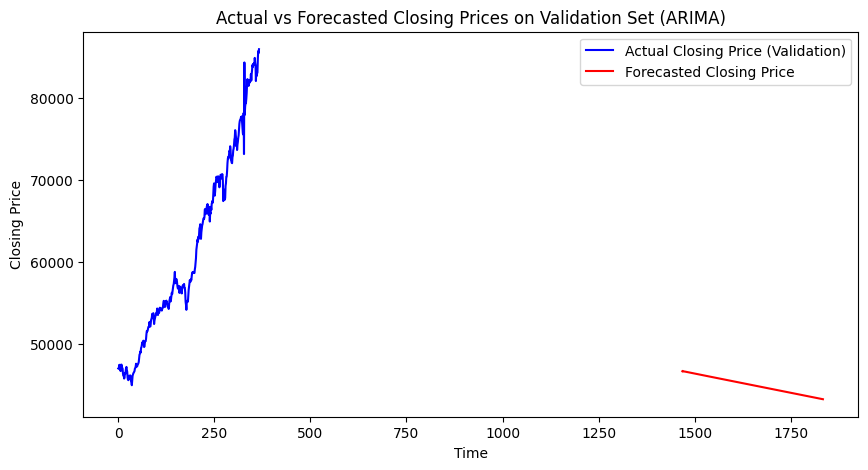

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Test MAE: 15953.034254783564
Test MSE: 331024114.09525925
Test RMSE: 18194.06810186384
Test MAPE: 18.60437696288303%
Test Accuracy: 0.4915254237288136
Test Precision: 0.4915254237288136
Test Recall: 1.0
Test F1-score: 0.6590909090909091
Test AUC-ROC: 0.4666666666666667


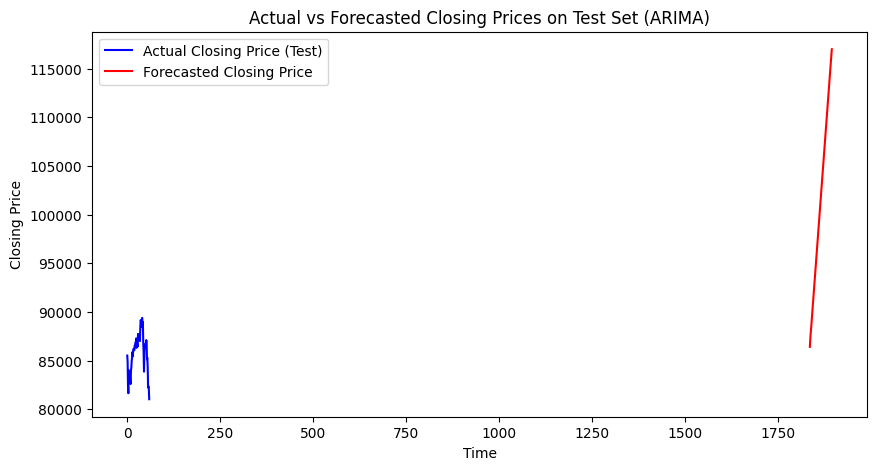

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Load the dataset (Training.csv)
train_data = pd.read_csv('Training.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

# Drop NaN values
train_data = train_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Split data into 80% training and 20% validation
train_size = int(len(train_data) * 0.8)
train_set, validation_set = train_data[:train_size], train_data[train_size:]

# Fit ARIMA model on the training set using the 'Close' column as the target variable
p, d, q = 5,2,0  # ARIMA parameters (p, d, q)
arima_model = ARIMA(train_set['Close'], order=(p, d, q))
arima_model_fit = arima_model.fit()

# Forecast the closing prices for the validation set
forecast_steps = len(validation_set)  # Number of steps to forecast
forecast = arima_model_fit.forecast(steps=forecast_steps)

# Calculate regression evaluation metrics on the validation set
mae = mean_absolute_error(validation_set['Close'], forecast)
mse = mean_squared_error(validation_set['Close'], forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(validation_set['Close'], forecast)

# Print regression evaluation metrics for the validation set
print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation RMSE: {rmse}")
print(f"Validation MAPE: {mape * 100}%")

# Define binary classification based on price increase (Price will go up or down)
true_binary = np.where(validation_set['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary = np.where(np.array(forecast) - validation_set['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary[:-1], pred_binary[:-1])  # Exclude the last element due to shift
precision = precision_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
recall = recall_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
f1 = f1_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
auc_roc = roc_auc_score(true_binary[:-1], forecast[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the validation set
print(f"Validation Accuracy: {accuracy}")
print(f"Validation Precision: {precision}")
print(f"Validation Recall: {recall}")
print(f"Validation F1-score: {f1}")
print(f"Validation AUC-ROC: {auc_roc}")

# Plot actual vs forecasted values for the validation set
plt.figure(figsize=(10, 5))
plt.plot(validation_set['Close'].values, label='Actual Closing Price (Validation)', color='blue')
plt.plot(forecast, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Validation Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()

# Load the test dataset (Testing.csv)
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    test_data[col] = pd.to_numeric(test_data[col], errors='coerce')

# Drop NaN values
test_data = test_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Fit ARIMA model on the full training dataset (Optional)
arima_model_full = ARIMA(train_data['Close'], order=(p, d, q))
arima_model_full_fit = arima_model_full.fit()

# Forecast closing prices for the test dataset
forecast_test_steps = len(test_data)
forecast_test = arima_model_full_fit.forecast(steps=forecast_test_steps)

# Calculate regression evaluation metrics on the test set
test_mae = mean_absolute_error(test_data['Close'], forecast_test)
test_mse = mean_squared_error(test_data['Close'], forecast_test)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(test_data['Close'], forecast_test)

# Print regression evaluation metrics for the test set
print(f"Test MAE: {test_mae}")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")
print(f"Test MAPE: {test_mape * 100}%")

# Define binary classification based on price increase for the test set
true_binary_test = np.where(test_data['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary_test = np.where(np.array(forecast_test) - test_data['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics for the test set
test_accuracy = accuracy_score(true_binary_test[:-1], pred_binary_test[:-1])
test_precision = precision_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
test_recall = recall_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
test_f1 = f1_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
test_auc_roc = roc_auc_score(true_binary_test[:-1], forecast_test[:-1])

# Print classification metrics for the test set
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1-score: {test_f1}")
print(f"Test AUC-ROC: {test_auc_roc}")

# Plot actual vs forecasted values for the test set
plt.figure(figsize=(10, 5))
plt.plot(test_data['Close'].values, label='Actual Closing Price (Test)', color='blue')
plt.plot(forecast_test, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Test Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()


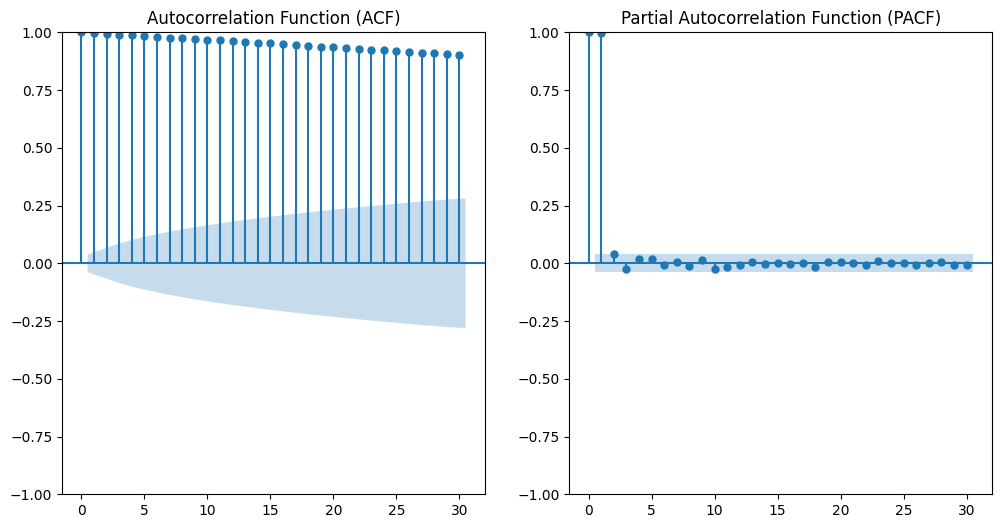

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/loc

Best ARIMA Order: (2, 1, 2) with AIC: 39748.44261119791


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Load the dataset
train_data = pd.read_csv('Training.csv')

# Convert relevant columns to numeric
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
train_data = train_data.dropna(subset=['Close'])

# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(train_data['Close'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

plt.subplot(122)
plot_pacf(train_data['Close'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

# Function to evaluate ARIMA model
def evaluate_arima(p, d, q):
    try:
        model = ARIMA(train_data['Close'], order=(p, d, q))
        model_fit = model.fit()
        return model_fit.aic  # or use model_fit.bic
    except:
        return float("inf")  # Return infinity if model fitting fails

# Grid Search for ARIMA parameters
best_aic = float("inf")
best_order = (0, 0, 0)

# Define the range for p, d, q
p_values = range(0, 3)  # Example: p = 0, 1, 2
d_values = range(0, 3)  # Example: d = 0, 1, 2
q_values = range(0, 3)  # Example: q = 0, 1, 2

# Perform grid search
for p in p_values:
    for d in d_values:
        for q in q_values:
            aic = evaluate_arima(p, d, q)
            if aic < best_aic:
                best_aic = aic
                best_order = (p, d, q)

print(f'Best ARIMA Order: {best_order} with AIC: {best_aic}')



In [ ]:
pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.1 MB/s eta 0:00:00


Training Data Types:
 Date      object
Open      object
High      object
Low       object
Close    float64
dtype: object
Testing Data Types:
 Date      object
Open     float64
High     float64
Low      float64
Close    float64
dtype: object
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=16.45 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=30073.149, Time=0.12 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=29173.008, Time=0.32 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.39 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=30071.150, Time=0.12 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=28968.276, Time=1.14 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=28857.078, Time=2.02 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=28746.216, Time=3.10 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=28710.569, Time=0.89 sec
 ARIMA(5,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=5.39 sec
 ARIMA(4,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=3.52 sec
 A

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


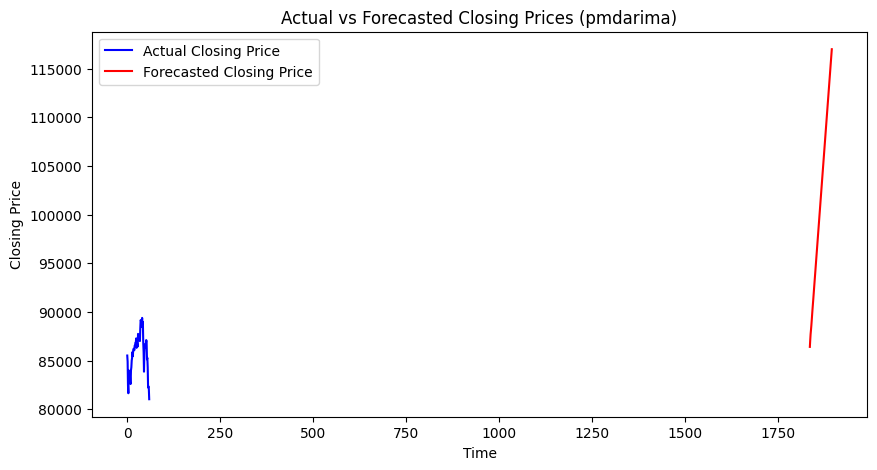

In [ ]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Check data types
print("Training Data Types:\n", train_data.dtypes)
print("Testing Data Types:\n", test_data.dtypes)

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')
    test_data[col] = pd.to_numeric(test_data[col], errors='coerce')

# Drop NaN values if present
train_data = train_data.dropna(subset=['Close', 'Open', 'High', 'Low'])
test_data = test_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Fit ARIMA model using pmdarima's auto_arima
exogenous_vars_train = train_data[['Open', 'High', 'Low']]  # Using other columns as predictors
model = auto_arima(train_data['Close'],
                   exogenous=exogenous_vars_train,
                   seasonal=False,  # Set to True if you want to include seasonal parameters
                   stepwise=True,
                   trace=True)

# Forecasting the future closing prices
forecast_steps = len(test_data)
exogenous_vars_test = test_data[['Open', 'High', 'Low']]  # Prepare test exogenous variables
forecast = model.predict(n_periods=forecast_steps, exogenous=exogenous_vars_test)

# Calculate regression evaluation metrics
mae = mean_absolute_error(test_data['Close'], forecast)
mse = mean_squared_error(test_data['Close'], forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test_data['Close'], forecast)

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")

# Define binary classification based on price increase
true_binary = np.where(test_data['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(np.array(forecast) - test_data['Close'].shift(-1) > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary[:-1], pred_binary[:-1])  # Exclude the last element due to shift
precision = precision_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
recall = recall_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
f1 = f1_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
auc_roc = roc_auc_score(true_binary[:-1], forecast[:-1])  # Use the forecast values for AUC-ROC

# Print classification metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(test_data['Close'].values, label='Actual Closing Price', color='blue')
plt.plot(forecast, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices (pmdarima)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()


With threhold value

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Validation MAE: 16755.958893749237
Validation MSE: 433979077.25898165
Validation RMSE: 20832.164488093447
Validation MAPE: 24.42038668869291%
Validation Accuracy: 0.36885245901639346
Validation Precision: 0.6666666666666666
Validation Recall: 0.008620689655172414
Validation F1-score: 0.01702127659574468
Validation AUC-ROC: 0.49845599588265566


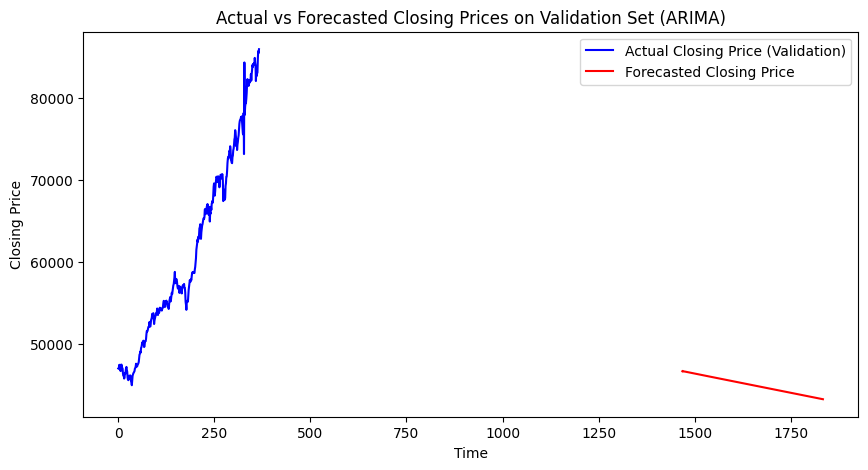

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Test MAE: 39422.671501441175
Test MSE: 1558441610.7515574
Test RMSE: 39477.102360122095
Test MAPE: 45.898112577995306%
Test Accuracy: 0.5084745762711864
Test Precision: 0.0
Test Recall: 0.0
Test F1-score: 0.0
Test AUC-ROC: 0.5321839080459769


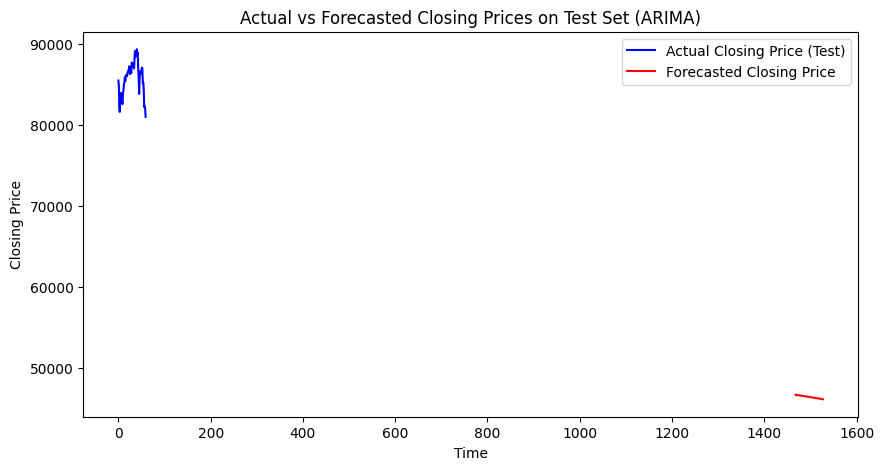

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Load the dataset (Training.csv)
train_data = pd.read_csv('Training.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

# Drop NaN values
train_data = train_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Split data into 80% training and 20% validation
train_size = int(len(train_data) * 0.8)
train_set, validation_set = train_data[:train_size], train_data[train_size:]

# Fit ARIMA model on the training set using the 'Close' column as the target variable
p, d, q = 5, 2, 0  # ARIMA parameters (p, d, q)
arima_model = ARIMA(train_set['Close'], order=(p, d, q))
arima_model_fit = arima_model.fit()

# Forecast the closing prices for the validation set
forecast_steps = len(validation_set)  # Number of steps to forecast
forecast = arima_model_fit.forecast(steps=forecast_steps)

# Calculate regression evaluation metrics on the validation set
mae = mean_absolute_error(validation_set['Close'], forecast)
mse = mean_squared_error(validation_set['Close'], forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(validation_set['Close'], forecast)

# Print regression evaluation metrics for the validation set
print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation RMSE: {rmse}")
print(f"Validation MAPE: {mape * 100}%")

# Define binary classification based on price increase (Price will go up or down)
true_binary = np.where(validation_set['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary = np.where(np.abs(np.array(forecast) - validation_set['Close'].shift(-1)) <= 100, 1, 0)

# Calculate classification evaluation metrics for validation
accuracy = accuracy_score(true_binary[:-1], pred_binary[:-1])  # Exclude the last element due to shift
precision = precision_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
recall = recall_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
f1 = f1_score(true_binary[:-1], pred_binary[:-1], zero_division=0)
auc_roc = roc_auc_score(true_binary[:-1], forecast[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the validation set
print(f"Validation Accuracy: {accuracy}")
print(f"Validation Precision: {precision}")
print(f"Validation Recall: {recall}")
print(f"Validation F1-score: {f1}")
print(f"Validation AUC-ROC: {auc_roc}")

# Plot actual vs forecasted values for the validation set
plt.figure(figsize=(10, 5))
plt.plot(validation_set['Close'].values, label='Actual Closing Price (Validation)', color='blue')
plt.plot(forecast, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Validation Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()

# -------------------------------------------
# Now process the Testing.csv dataset
# Load the test dataset (Testing.csv)
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric
for col in ['Close', 'Open', 'High', 'Low']:
    test_data[col] = pd.to_numeric(test_data[col], errors='coerce')

# Drop NaN values
test_data = test_data.dropna(subset=['Close', 'Open', 'High', 'Low'])

# Forecast the closing prices for the test set
forecast_test_steps = len(test_data)  # Number of steps to forecast
forecast_test = arima_model_fit.forecast(steps=forecast_test_steps)

# Calculate regression evaluation metrics on the test set
mae_test = mean_absolute_error(test_data['Close'], forecast_test)
mse_test = mean_squared_error(test_data['Close'], forecast_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(test_data['Close'], forecast_test)

# Print regression evaluation metrics for the test set
print(f"Test MAE: {mae_test}")
print(f"Test MSE: {mse_test}")
print(f"Test RMSE: {rmse_test}")
print(f"Test MAPE: {mape_test * 100}%")

# Define binary classification based on price increase for the test set
true_binary_test = np.where(test_data['Close'].diff().shift(-1) > 0, 1, 0)  # 1 if next price is higher
pred_binary_test = np.where(np.abs(np.array(forecast_test) - test_data['Close'].shift(-1)) <= 100, 1, 0)

# Calculate classification evaluation metrics for test set
accuracy_test = accuracy_score(true_binary_test[:-1], pred_binary_test[:-1])  # Exclude the last element due to shift
precision_test = precision_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
recall_test = recall_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
f1_test = f1_score(true_binary_test[:-1], pred_binary_test[:-1], zero_division=0)
auc_roc_test = roc_auc_score(true_binary_test[:-1], forecast_test[:-1])  # Use forecast for AUC-ROC

# Print classification metrics for the test set
print(f"Test Accuracy: {accuracy_test}")
print(f"Test Precision: {precision_test}")
print(f"Test Recall: {recall_test}")
print(f"Test F1-score: {f1_test}")
print(f"Test AUC-ROC: {auc_roc_test}")

# Plot actual vs forecasted values for the test set
plt.figure(figsize=(10, 5))
plt.plot(test_data['Close'].values, label='Actual Closing Price (Test)', color='blue')
plt.plot(forecast_test, label='Forecasted Closing Price', color='red')
plt.legend()
plt.title('Actual vs Forecasted Closing Prices on Test Set (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.show()


# **SARIMA**

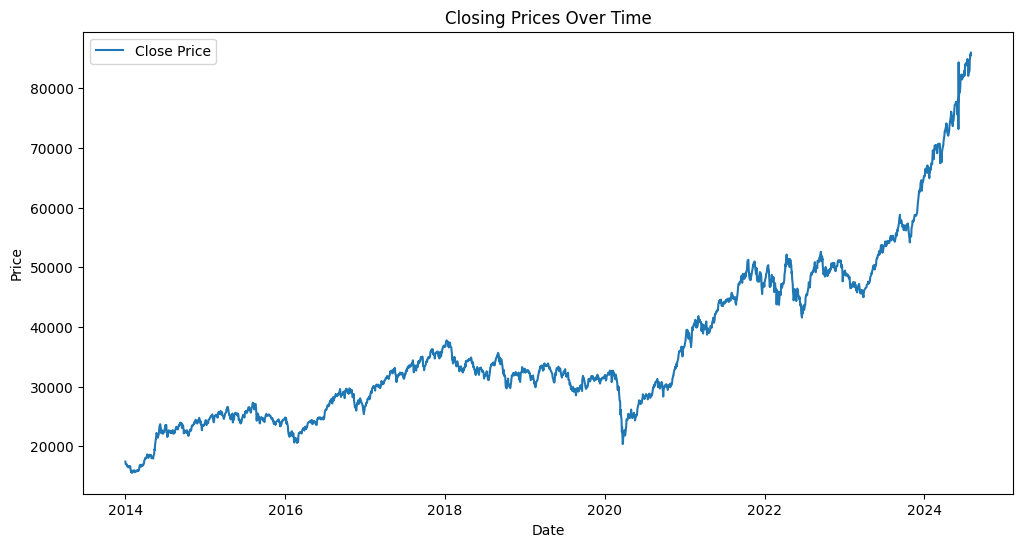

ADF Statistic: 2.5373509045055127
p-value: 0.9990609134529306


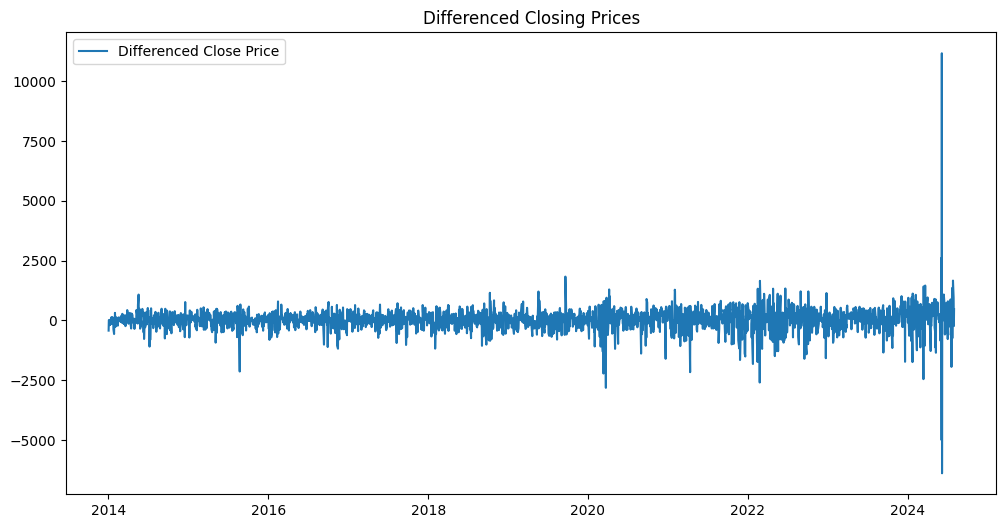

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Mean Absolute Error (MAE): 1579.2349134058354
Mean Squared Error (MSE): 4781679.566094003
Root Mean Squared Error (RMSE): 2186.705184997283
Mean Absolute Percentage Error (MAPE): 1.87032731614573%
Accuracy: 0.7
Precision: 0.5333333333333333
Recall: 0.8
F1 Score: 0.64
AUC-ROC: 0.7250000000000001


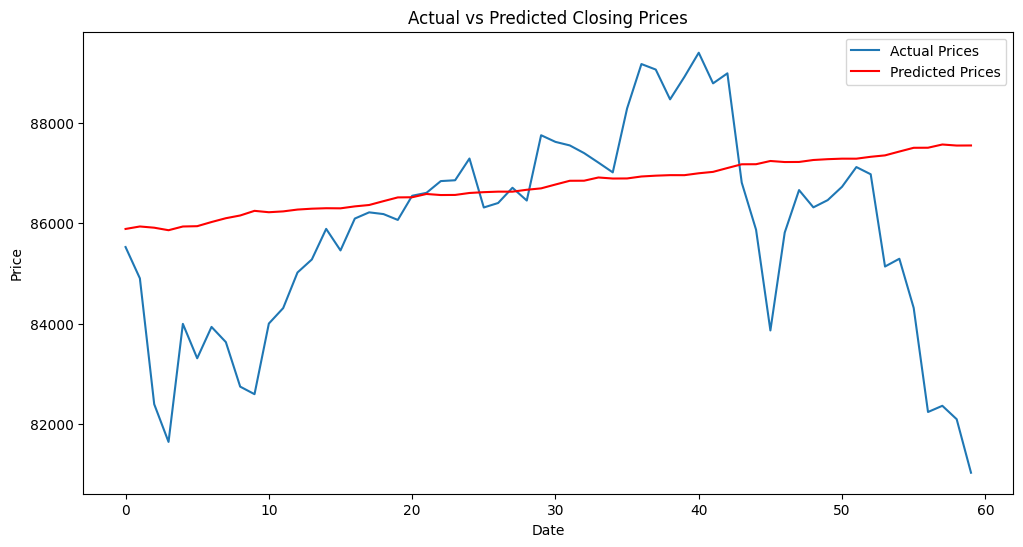

In [ ]:
# Step 1: Load the Data
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load your dataset
data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Ensure the 'Date' column is in datetime format with the correct format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data.set_index('Date', inplace=True)

# Step 2: Visualize the Closing Prices
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price')
plt.title('Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 3: Check for Stationarity
result = adfuller(data['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Step 4: Differencing if needed
if result[1] > 0.05:
    data['Close_diff'] = data['Close'].diff().dropna()
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close_diff'], label='Differenced Close Price')
    plt.title('Differenced Closing Prices')
    plt.legend()
    plt.show()

# Step 5: Determine SARIMA Parameters (p, d, q)(P, D, Q, s)
# For this example, let's assume you choose the parameters
p = 1
d = 1  # Based on the stationarity test
q = 1
P = 1
D = 1  # Seasonal differencing
Q = 1
s = 12  # Assuming monthly seasonality

# Step 6: Fit the SARIMA Model
model = SARIMAX(data['Close'], order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit(disp=False)

# Step 7: Forecast Future Values
n_forecast = len(test_data)
forecast = model_fit.forecast(steps=n_forecast)

# Step 8: Evaluate the Model
test_data['Predicted'] = forecast.values

# Calculate metrics
# MAE
mae = mean_absolute_error(test_data['Close'], test_data['Predicted'])
print(f'Mean Absolute Error (MAE): {mae}')

# MSE
mse = mean_squared_error(test_data['Close'], test_data['Predicted'])
print(f'Mean Squared Error (MSE): {mse}')

# RMSE
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# MAPE
mape = np.mean(np.abs((test_data['Close'] - test_data['Predicted']) / test_data['Close'])) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')

# For binary classification metrics, determine a threshold to classify predictions
threshold = np.mean(test_data['Predicted'])  # Adjust threshold as needed
y_pred_binary = (test_data['Predicted'] >= threshold).astype(int)
y_true_binary = (test_data['Close'] >= threshold).astype(int)

# Accuracy
accuracy = accuracy_score(y_true_binary, y_pred_binary)
print(f'Accuracy: {accuracy}')

# Precision
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'Precision: {precision}')

# Recall
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'Recall: {recall}')

# F1 Score
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'F1 Score: {f1}')

# AUC-ROC
auc_roc = roc_auc_score(y_true_binary, y_pred_binary)
print(f'AUC-ROC: {auc_roc}')

# Plot the predictions against the actual values
plt.figure(figsize=(12, 6))
plt.plot(test_data['Close'], label='Actual Prices')
plt.plot(test_data['Predicted'], label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


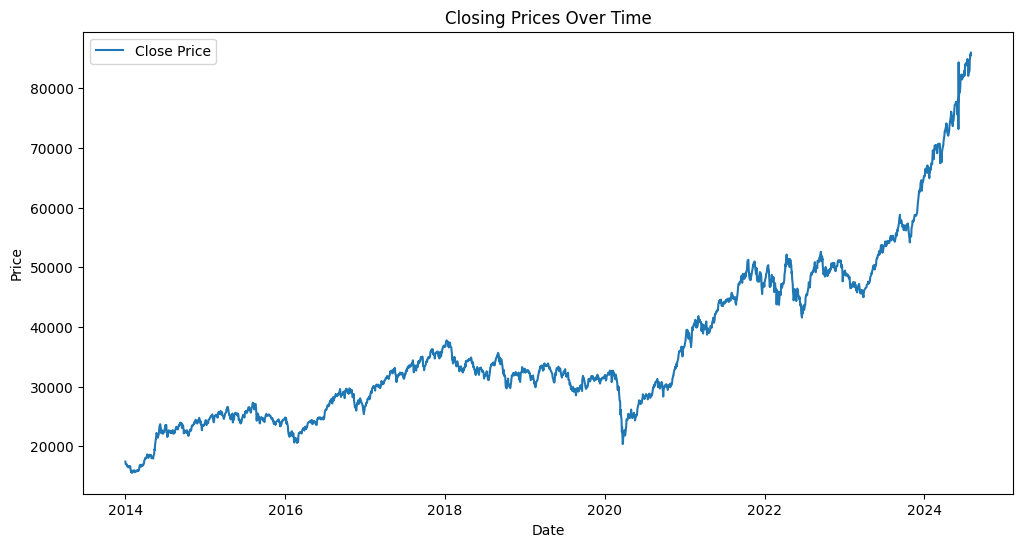

ADF Statistic: 2.5373509045055127
p-value: 0.9990609134529306


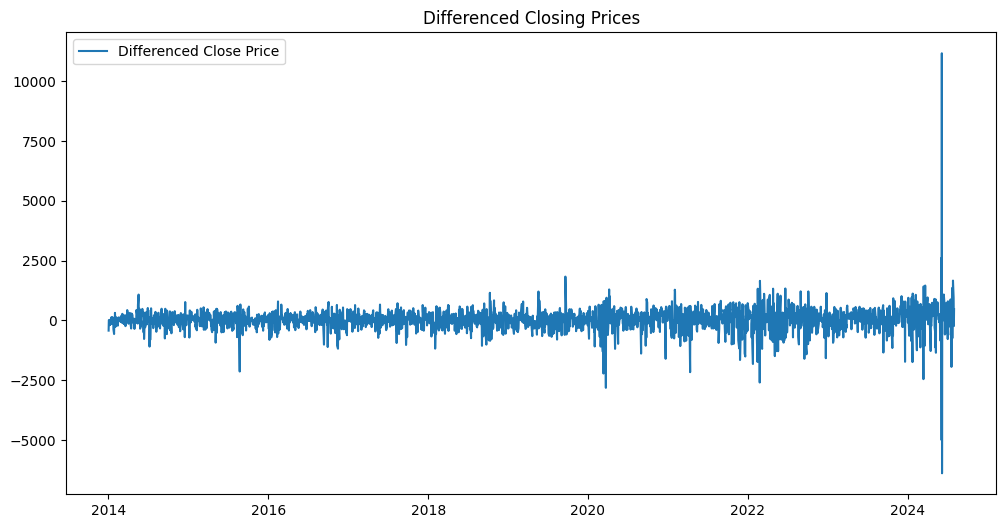


Evaluating SARIMA model with seasonal period s = 6


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


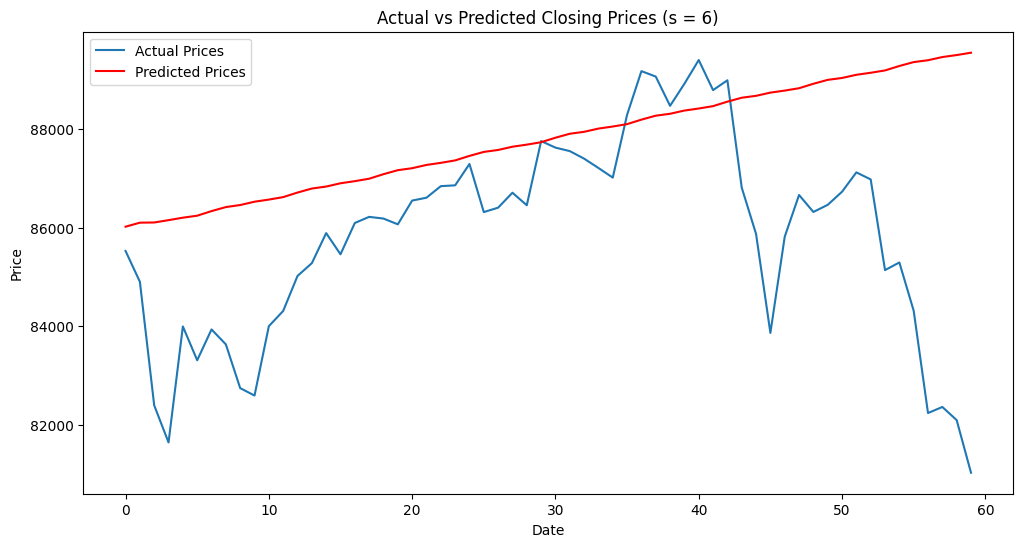


Evaluating SARIMA model with seasonal period s = 12


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


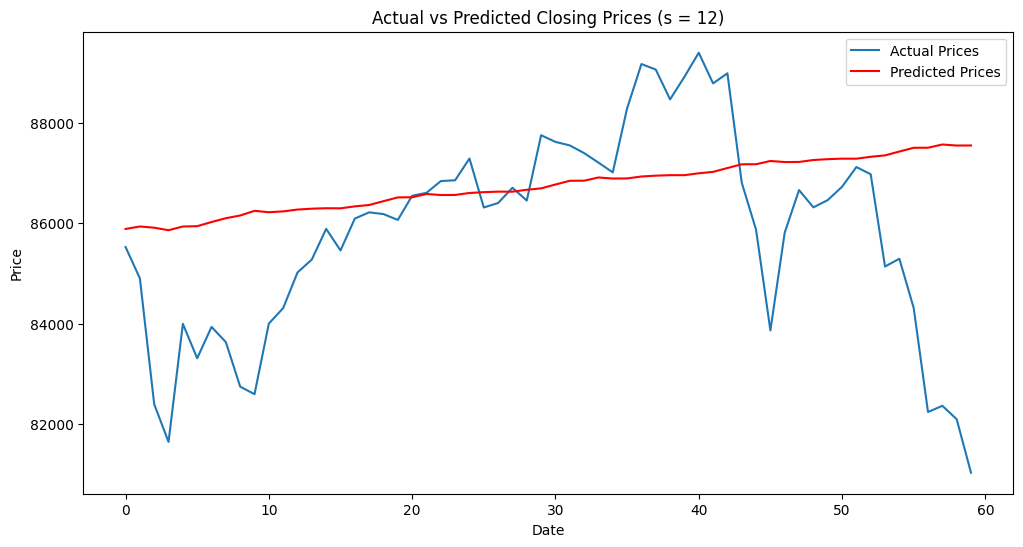


Evaluating SARIMA model with seasonal period s = 24


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/stat

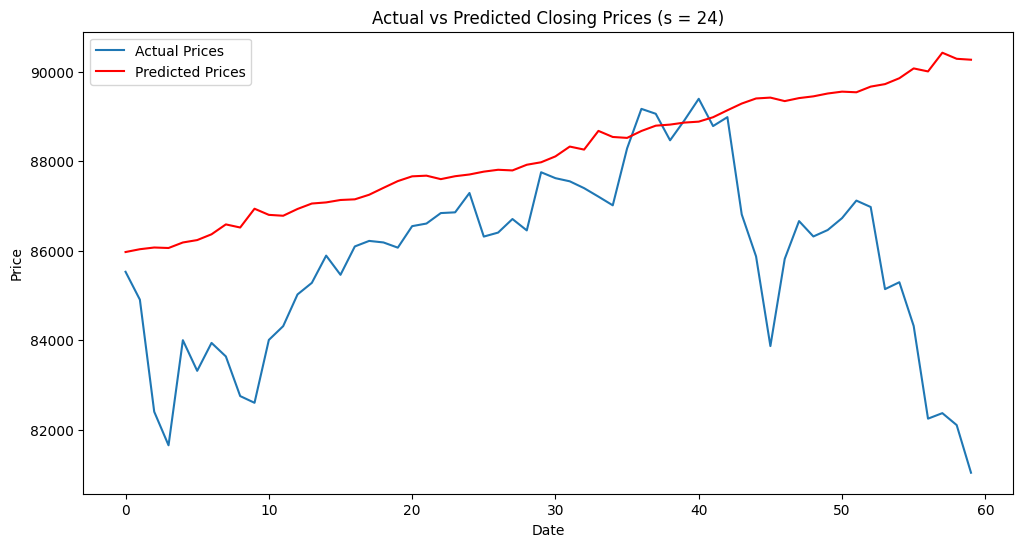


Summary of Results:
    s          MAE           MSE         RMSE      MAPE  Accuracy  Precision  \
0   6  2093.233810  8.130832e+06  2851.461404  2.484585  0.633333   0.266667   
1  12  1579.234913  4.781680e+06  2186.705185  1.870327  0.700000   0.533333   
2  24  2367.924750  1.009802e+07  3177.737462  2.808177  0.650000   0.275862   

   Recall  F1 Score   AUC-ROC  
0     1.0  0.421053  0.788462  
1     0.8  0.640000  0.725000  
2     1.0  0.432432  0.798077  


In [ ]:
# Step 1: Load the Data
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load your dataset
data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Ensure the 'Date' column is in datetime format with the correct format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data.set_index('Date', inplace=True)

# Step 2: Visualize the Closing Prices
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price')
plt.title('Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 3: Check for Stationarity
result = adfuller(data['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Step 4: Differencing if needed
if result[1] > 0.05:
    data['Close_diff'] = data['Close'].diff().dropna()
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close_diff'], label='Differenced Close Price')
    plt.title('Differenced Closing Prices')
    plt.legend()
    plt.show()

# Step 5: Determine SARIMA Parameters (p, d, q)(P, D, Q, s)
# Fixed parameters
p = 1
d = 1  # Based on the stationarity test
q = 1
P = 1
D = 1  # Seasonal differencing
Q = 1

# List of seasonal periods to test
s_values = [6, 12, 24]  # Adjust these values based on your understanding of seasonality
results = []

# Loop through each seasonal period
for s in s_values:
    print(f"\nEvaluating SARIMA model with seasonal period s = {s}")

    # Step 6: Fit the SARIMA Model
    model = SARIMAX(data['Close'], order=(p, d, q), seasonal_order=(P, D, Q, s))
    model_fit = model.fit(disp=False)

    # Step 7: Forecast Future Values
    n_forecast = len(test_data)
    forecast = model_fit.forecast(steps=n_forecast)

    # Step 8: Evaluate the Model
    test_data['Predicted'] = forecast.values

    # Calculate metrics
    mae = mean_absolute_error(test_data['Close'], test_data['Predicted'])
    mse = mean_squared_error(test_data['Close'], test_data['Predicted'])
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_data['Close'] - test_data['Predicted']) / test_data['Close'])) * 100

    # For binary classification metrics, determine a threshold to classify predictions
    threshold = np.mean(test_data['Predicted'])  # Adjust threshold as needed
    y_pred_binary = (test_data['Predicted'] >= threshold).astype(int)
    y_true_binary = (test_data['Close'] >= threshold).astype(int)

    # Accuracy
    accuracy = accuracy_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    auc_roc = roc_auc_score(y_true_binary, y_pred_binary)

    # Store results
    results.append({
        's': s,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC-ROC': auc_roc
    })

    # Plot the predictions against the actual values
    plt.figure(figsize=(12, 6))
    plt.plot(test_data['Close'], label='Actual Prices')
    plt.plot(test_data['Predicted'], label='Predicted Prices', color='red')
    plt.title(f'Actual vs Predicted Closing Prices (s = {s})')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Step 9: Summarize results
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df)


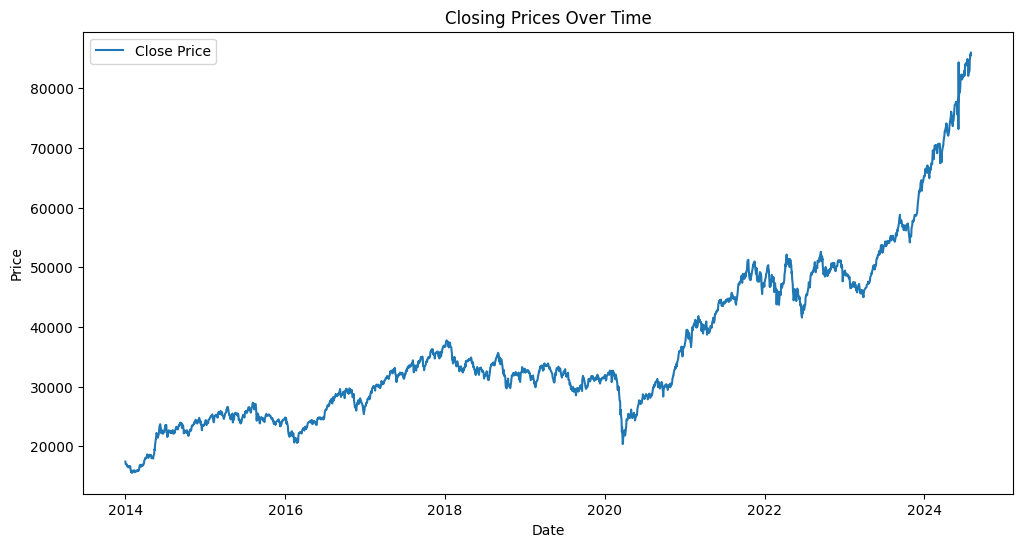

ADF Statistic: 2.5373509045055127
p-value: 0.9990609134529306


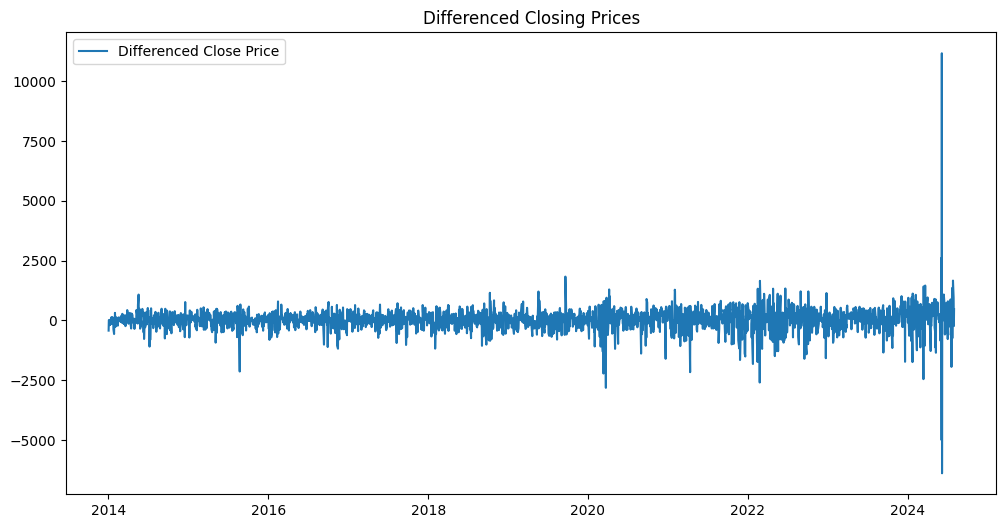

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Mean Absolute Error (MAE): 1579.2349134058354
Mean Squared Error (MSE): 4781679.566094003
Root Mean Squared Error (RMSE): 2186.705184997283
Mean Absolute Percentage Error (MAPE): 1.87032731614573%
Accuracy: 0.7
Precision: 0.5333333333333333
Recall: 0.8
F1 Score: 0.64
AUC-ROC: 0.7250000000000001


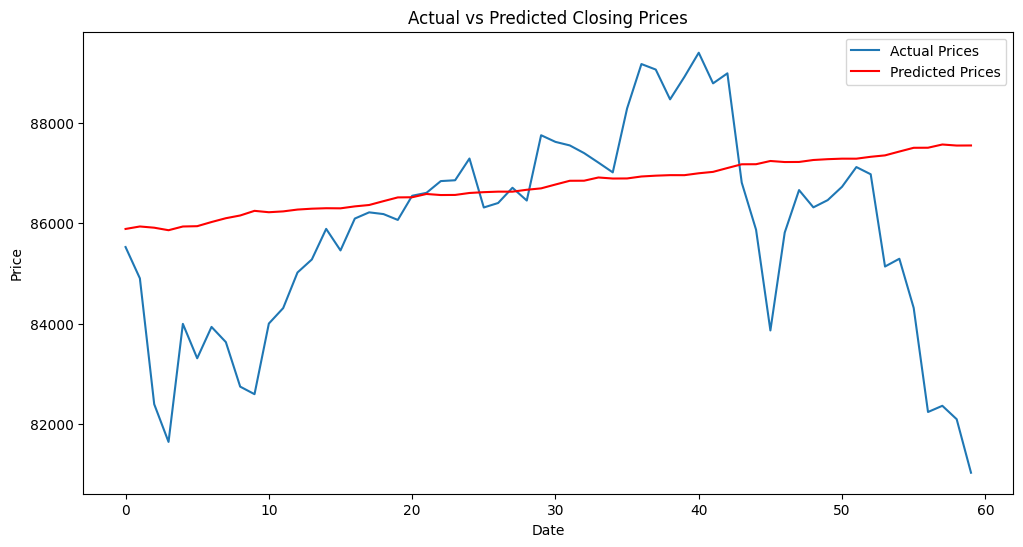

In [ ]:
# Step 1: Load the Data
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load your dataset
data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Ensure the 'Date' column is in datetime format with the correct format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data.set_index('Date', inplace=True)

# Step 2: Visualize the Closing Prices
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price')
plt.title('Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 3: Check for Stationarity
result = adfuller(data['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Step 4: Differencing if needed
if result[1] > 0.05:
    data['Close_diff'] = data['Close'].diff().dropna()
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close_diff'], label='Differenced Close Price')
    plt.title('Differenced Closing Prices')
    plt.legend()
    plt.show()

# Step 5: Determine SARIMA Parameters (p, d, q)(P, D, Q, s)
# For this example, let's assume you choose the parameters
p = 1
d = 1  # Based on the stationarity test
q = 1
P = 1
D = 1  # Seasonal differencing
Q = 1
s = 12  # Assuming monthly seasonality

# Step 6: Fit the SARIMA Model
model = SARIMAX(data['Close'], order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit(disp=False)

# Step 7: Forecast Future Values
n_forecast = len(test_data)
forecast = model_fit.forecast(steps=n_forecast)

# Step 8: Evaluate the Model
test_data['Predicted'] = forecast.values

# Calculate metrics
# MAE
mae = mean_absolute_error(test_data['Close'], test_data['Predicted'])
print(f'Mean Absolute Error (MAE): {mae}')

# MSE
mse = mean_squared_error(test_data['Close'], test_data['Predicted'])
print(f'Mean Squared Error (MSE): {mse}')

# RMSE
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# MAPE
mape = np.mean(np.abs((test_data['Close'] - test_data['Predicted']) / test_data['Close'])) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')

# For binary classification metrics, determine a threshold to classify predictions
threshold = np.mean(test_data['Predicted'])  # Adjust threshold as needed
y_pred_binary = (test_data['Predicted'] >= threshold).astype(int)
y_true_binary = (test_data['Close'] >= threshold).astype(int)

# Accuracy
accuracy = accuracy_score(y_true_binary, y_pred_binary)
print(f'Accuracy: {accuracy}')

# Precision
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'Precision: {precision}')

# Recall
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'Recall: {recall}')

# F1 Score
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
print(f'F1 Score: {f1}')

# AUC-ROC (only if both classes are present in y_true_binary)
if len(np.unique(y_true_binary)) > 1:
    auc_roc = roc_auc_score(y_true_binary, y_pred_binary)
    print(f'AUC-ROC: {auc_roc}')
else:
    print("AUC-ROC cannot be calculated because only one class is present in y_true_binary.")

# Plot the predictions against the actual values
plt.figure(figsize=(12, 6))
plt.plot(test_data['Close'], label='Actual Prices')
plt.plot(test_data['Predicted'], label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


with threshold and shift

Using `shift()` in time series analysis, especially when evaluating forecasts, helps to align the predicted values with the true target values for accurate comparisons. Here’s a brief overview of its use in your context:

### Why Use `shift()`?

1. **Alignment for Comparison**:
   - When you make a forecast for a future time step (e.g., tomorrow's closing price), you need to compare it against the actual observed value from the same time step. The `shift()` function helps shift the observed series down by one time step, so you can accurately compare forecasts to the correct actual values.

2. **Price Movement Evaluation**:
   - When calculating whether the price has increased or decreased, `shift()` is useful to reference the previous value. For example, if you want to know if the price went up compared to the previous day, you can use `shift()` to access the previous day’s price.

### Example of Usage:
In your code, this line is crucial:
```python
true_binary = np.where(validation_set['Close'].diff().shift(-1) > 0, 1, 0)
```
- **Explanation**: This line creates a binary array indicating whether the closing price increased the next day. The `diff()` calculates the difference between consecutive days, and `shift(-1)` aligns the differences with the current day.

### Should You Use It?
- **Yes**, you should use `shift()` if you want to compare forecasts against the appropriate true values and assess the directional movement of prices accurately.
- However, if you omit `shift()`, you might incorrectly align your predictions with the actual values, leading to inaccurate evaluation metrics.

### Alternative Without Shift:
If you want to evaluate the forecast accuracy without `shift()`, you could compare the forecast directly with the actual closing prices, but be aware that you might not be capturing the true movement of prices effectively. For example:

```python
pred_binary = np.where(np.array(forecast) - validation_set['Close'] > 0, 1, 0)
```

But in this case, you would not be assessing whether the next day's price goes up based on the previous day’s forecast.

### Summary
Using `shift()` is essential for maintaining the correct temporal alignment in your time series forecasting tasks, ensuring that you're evaluating your predictions against the intended targets accurately.

# **CNN**

CNN 1D

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0126
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 13/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 14/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 15/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 16/50
81/81 ━━━━━━━━━━━━

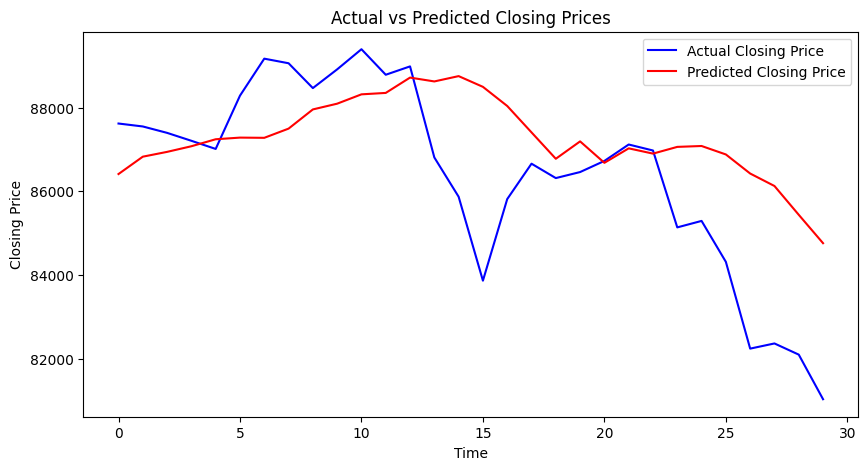

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days
time_step = 30
X_train, y_train = create_dataset(train_data['Close'].values, time_step)
X_test, y_test = create_dataset(test_data['Close'].values, time_step)

# Reshape input to be [samples, time steps, features] for 1D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build the CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

# Define binary classification based on price increase
true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(y_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary, pred_binary)
precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)
f1 = f1_score(true_binary, pred_binary, zero_division=0)
auc_roc = roc_auc_score(true_binary, y_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Optional: Plotting predicted vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0122 - val_loss: 0.0032
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 0.0033
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 0.0064
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 7.3830e-04
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 5.8797e-04
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 3.2230e-04
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 5.7781e-04
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 0.0027
Epoch 10/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.5728e-04 - val_loss: 7.4851e-04
Epoch 11/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7038e-04 - val_loss: 6.0501e-04
Epoch 12/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1

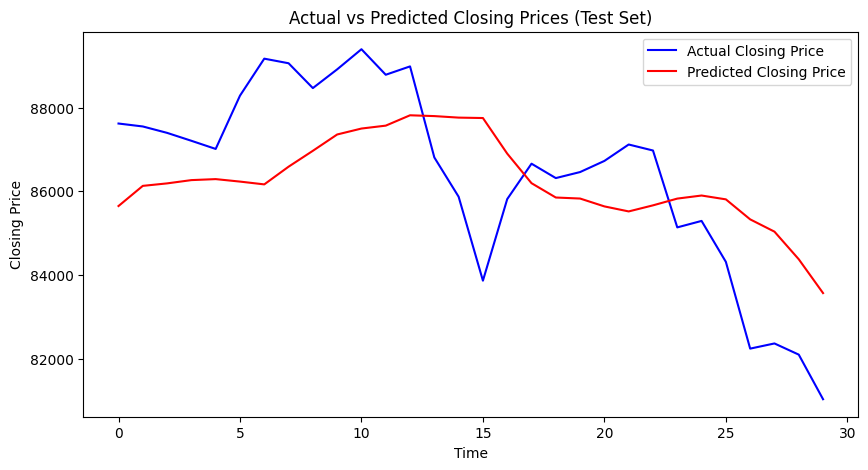

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Split training data into training and validation sets (80-20 split)
split_index = int(len(train_data) * 0.8)
train_set = train_data[:split_index]
val_set = train_data[split_index:]

# Prepare the dataset for the CNN
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days
time_step = 30
X_train, y_train = create_dataset(train_set['Close'].values, time_step)
X_val, y_val = create_dataset(val_set['Close'].values, time_step)
X_test, y_test = create_dataset(test_data['Close'].values, time_step)

# Reshape input to be [samples, time steps, features] for 1D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build the CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Make predictions on validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Inverse transform the predictions and actual values
y_val_pred_inverse = scaler.inverse_transform(y_val_pred)
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_pred_inverse = scaler.inverse_transform(y_test_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics for validation set
mae_val = mean_absolute_error(y_val_inverse, y_val_pred_inverse)
mse_val = mean_squared_error(y_val_inverse, y_val_pred_inverse)
rmse_val = np.sqrt(mse_val)
mape_val = mean_absolute_percentage_error(y_val_inverse, y_val_pred_inverse)

# Calculate regression evaluation metrics for test set
mae_test = mean_absolute_error(y_test_inverse, y_test_pred_inverse)
mse_test = mean_squared_error(y_test_inverse, y_test_pred_inverse)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test_inverse, y_test_pred_inverse)

# Binary classification metrics based on price increase for validation and test sets
# Define binary labels
val_true_binary = np.where(y_val_inverse[1:] - y_val_inverse[:-1] > 0, 1, 0)
val_pred_binary = np.where(y_val_pred_inverse[:-1] - y_val_inverse[:-1] > 0, 1, 0)
test_true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)
test_pred_binary = np.where(y_test_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification metrics for validation set
accuracy_val = accuracy_score(val_true_binary, val_pred_binary)
precision_val = precision_score(val_true_binary, val_pred_binary, zero_division=0)
recall_val = recall_score(val_true_binary, val_pred_binary, zero_division=0)
f1_val = f1_score(val_true_binary, val_pred_binary, zero_division=0)
auc_roc_val = roc_auc_score(val_true_binary, y_val_pred_inverse[:-1])

# Calculate classification metrics for test set
accuracy_test = accuracy_score(test_true_binary, test_pred_binary)
precision_test = precision_score(test_true_binary, test_pred_binary, zero_division=0)
recall_test = recall_score(test_true_binary, test_pred_binary, zero_division=0)
f1_test = f1_score(test_true_binary, test_pred_binary, zero_division=0)
auc_roc_test = roc_auc_score(test_true_binary, y_test_pred_inverse[:-1])

# Print evaluation metrics for validation set
print("Validation Set Metrics:")
print(f"MAE: {mae_val}")
print(f"MSE: {mse_val}")
print(f"RMSE: {rmse_val}")
print(f"MAPE: {mape_val * 100}%")
print(f"Accuracy: {accuracy_val}")
print(f"Precision: {precision_val}")
print(f"Recall: {recall_val}")
print(f"F1-score: {f1_val}")
print(f"AUC-ROC: {auc_roc_val}")

# Print evaluation metrics for test set
print("\nTest Set Metrics:")
print(f"MAE: {mae_test}")
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"MAPE: {mape_test * 100}%")
print(f"Accuracy: {accuracy_test}")
print(f"Precision: {precision_test}")
print(f"Recall: {recall_test}")
print(f"F1-score: {f1_test}")
print(f"AUC-ROC: {auc_roc_test}")

# Plotting predicted vs actual values for test set
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_test_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices (Test Set)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


CNN 2D

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0220
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 13/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 14/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 15/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 16/50
81/81 ━

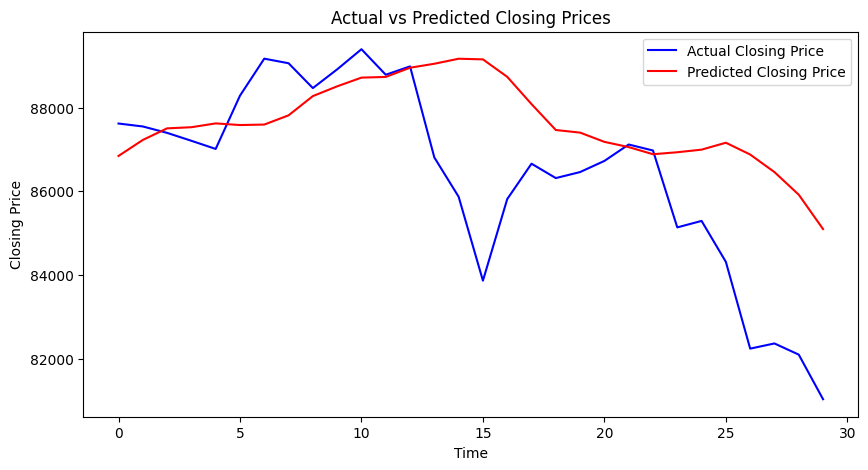

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_2d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_2d_dataset(train_data['Close'].values, time_step, num_features)
X_test, y_test = create_2d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, height, width, channels] for 2D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Build the 2D CNN model
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(2, 1), activation='relu', input_shape=(time_step, num_features, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

# Define binary classification based on price increase
true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(y_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary, pred_binary)
precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)
f1 = f1_score(true_binary, pred_binary, zero_division=0)
auc_roc = roc_auc_score(true_binary, y_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Optional: Plotting predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0128 - val_loss: 0.0011
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.8517e-04
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 3.6165e-04
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.6035e-04 - val_loss: 0.0016
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 8.4021e-04 - val_loss: 9.9028e-04
Epoch 10/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.9364e-04 - val_loss: 0.0027
Epoch 11/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.9947e-04 - val_loss: 0.0020
Epoch 12/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

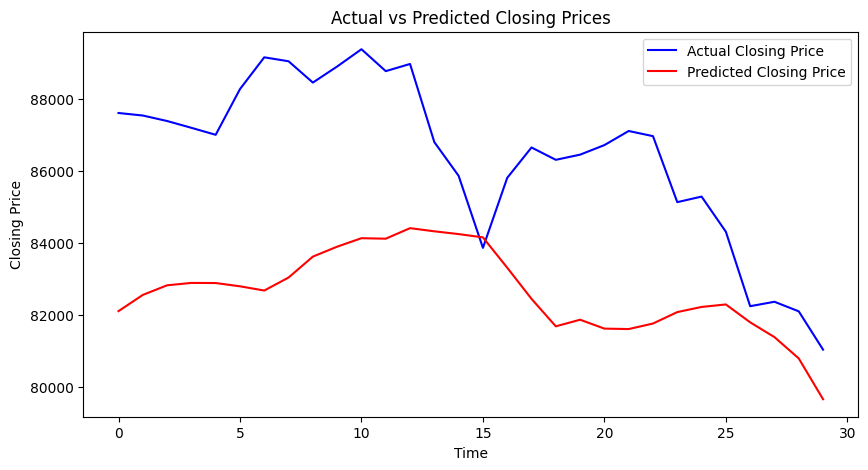

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Split the training set into train and validation sets (80-20 split)
train_size = int(len(train_data) * 0.8)
train, validation = train_data[:train_size], train_data[train_size:]

# Prepare the dataset for the CNN
def create_2d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_2d_dataset(train['Close'].values, time_step, num_features)
X_val, y_val = create_2d_dataset(validation['Close'].values, time_step, num_features)
X_test, y_test = create_2d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, height, width, channels] for 2D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Build the 2D CNN model
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(2, 1), activation='relu', input_shape=(time_step, num_features, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Make predictions for validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Inverse transform the predictions
y_val_pred_inverse = scaler.inverse_transform(y_val_pred)
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_pred_inverse = scaler.inverse_transform(y_test_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics for validation
val_mae = mean_absolute_error(y_val_inverse, y_val_pred_inverse)
val_mse = mean_squared_error(y_val_inverse, y_val_pred_inverse)
val_rmse = np.sqrt(val_mse)
val_mape = mean_absolute_percentage_error(y_val_inverse, y_val_pred_inverse)

# Calculate regression evaluation metrics for test
test_mae = mean_absolute_error(y_test_inverse, y_test_pred_inverse)
test_mse = mean_squared_error(y_test_inverse, y_test_pred_inverse)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test_inverse, y_test_pred_inverse)

# Define binary classification based on price increase for validation and test sets
val_true_binary = np.where(y_val_inverse[1:] - y_val_inverse[:-1] > 0, 1, 0)
val_pred_binary = np.where(y_val_pred_inverse[:-1] - y_val_inverse[:-1] > 0, 1, 0)
test_true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)
test_pred_binary = np.where(y_test_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for validation
val_accuracy = accuracy_score(val_true_binary, val_pred_binary)
val_precision = precision_score(val_true_binary, val_pred_binary, zero_division=0)
val_recall = recall_score(val_true_binary, val_pred_binary, zero_division=0)
val_f1 = f1_score(val_true_binary, val_pred_binary, zero_division=0)
val_auc_roc = roc_auc_score(val_true_binary, y_val_pred_inverse[:-1])

# Calculate classification evaluation metrics for test
test_accuracy = accuracy_score(test_true_binary, test_pred_binary)
test_precision = precision_score(test_true_binary, test_pred_binary, zero_division=0)
test_recall = recall_score(test_true_binary, test_pred_binary, zero_division=0)
test_f1 = f1_score(test_true_binary, test_pred_binary, zero_division=0)
test_auc_roc = roc_auc_score(test_true_binary, y_test_pred_inverse[:-1])

# Print validation evaluation metrics
print("Validation Metrics:")
print(f"MAE: {val_mae}")
print(f"MSE: {val_mse}")
print(f"RMSE: {val_rmse}")
print(f"MAPE: {val_mape * 100}%")
print(f"Accuracy: {val_accuracy}")
print(f"Precision: {val_precision}")
print(f"Recall: {val_recall}")
print(f"F1-score: {val_f1}")
print(f"AUC-ROC: {val_auc_roc}")

# Print test evaluation metrics
print("Test Metrics:")
print(f"MAE: {test_mae}")
print(f"MSE: {test_mse}")
print(f"RMSE: {test_rmse}")
print(f"MAPE: {test_mape * 100}%")
print(f"Accuracy: {test_accuracy}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"F1-score: {test_f1}")
print(f"AUC-ROC: {test_auc_roc}")

# Optional: Plotting predicted vs actual values for test set
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_test_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0215
Epoch 2/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033
Epoch 3/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024
Epoch 4/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024
Epoch 5/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024
Epoch 6/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021
Epoch 7/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 8/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 9/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 10/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 11/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 12/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 13/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016
Epoch 14/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 15/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoc

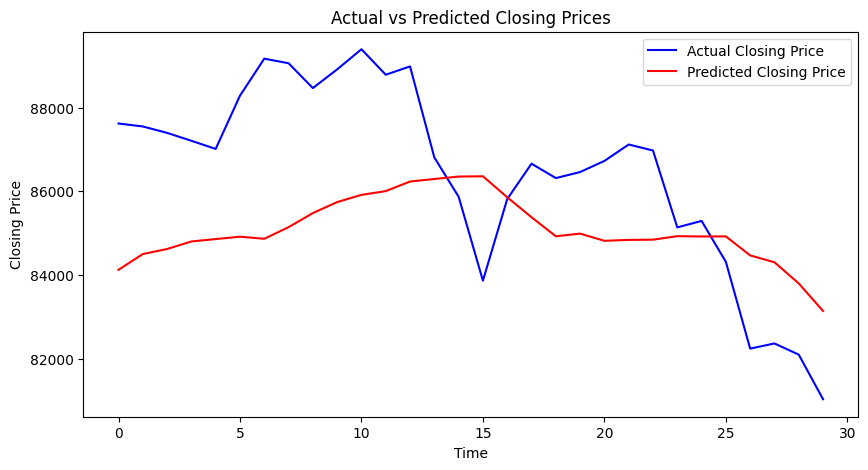

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_2d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_2d_dataset(train_data['Close'].values, time_step, num_features)
X_test, y_test = create_2d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, height, width, channels] for 2D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Build the 2D CNN model
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(2, 1), activation='relu', input_shape=(time_step, num_features, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=1)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

# Define binary classification based on price increase
true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(y_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary, pred_binary)
precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)
f1 = f1_score(true_binary, pred_binary, zero_division=0)
auc_roc = roc_auc_score(true_binary, y_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Optional: Plotting predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0087 - val_loss: 5.6577e-04
Epoch 2/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 5.2484e-04
Epoch 3/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 5.1207e-04
Epoch 4/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 4.9526e-04
Epoch 5/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.5902e-04 - val_loss: 6.8036e-04
Epoch 6/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8210e-04 - val_loss: 0.0018
Epoch 7/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.0677e-04 - val_loss: 3.9145e-04
Epoch 8/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.6194e-04 - val_loss: 6.3883e-04
Epoch 9/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7922e-04 - val_loss: 2.4013e-04
Epoch 10/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.2086e-04 - val_loss: 0.0033
Epoch 11/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0465e-04 - val_loss: 0.0012
E

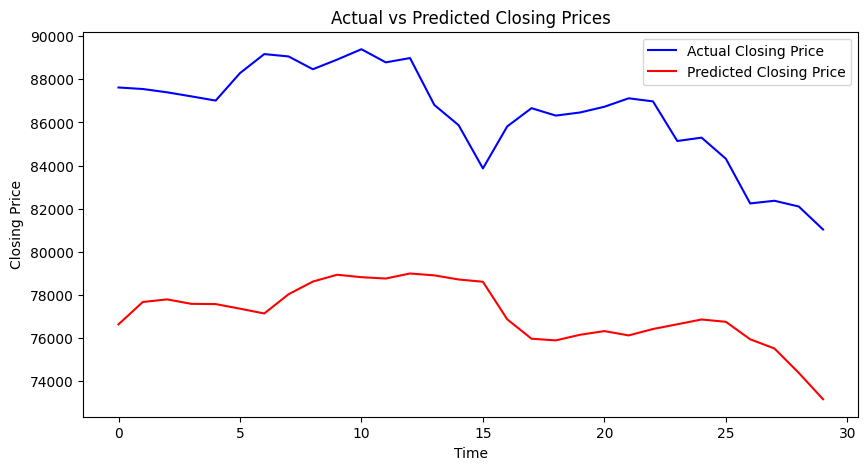

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Split the training set into train and validation sets (80-20 split)
train_size = int(len(train_data) * 0.8)
train, validation = train_data[:train_size], train_data[train_size:]

# Prepare the dataset for the CNN
def create_2d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_2d_dataset(train['Close'].values, time_step, num_features)
X_val, y_val = create_2d_dataset(validation['Close'].values, time_step, num_features)
X_test, y_test = create_2d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, height, width, channels] for 2D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Build the 2D CNN model
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(2, 1), activation='relu', input_shape=(time_step, num_features, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=150, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Make predictions for validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Inverse transform the predictions
y_val_pred_inverse = scaler.inverse_transform(y_val_pred)
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_pred_inverse = scaler.inverse_transform(y_test_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics for validation
val_mae = mean_absolute_error(y_val_inverse, y_val_pred_inverse)
val_mse = mean_squared_error(y_val_inverse, y_val_pred_inverse)
val_rmse = np.sqrt(val_mse)
val_mape = mean_absolute_percentage_error(y_val_inverse, y_val_pred_inverse)

# Calculate regression evaluation metrics for test
test_mae = mean_absolute_error(y_test_inverse, y_test_pred_inverse)
test_mse = mean_squared_error(y_test_inverse, y_test_pred_inverse)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test_inverse, y_test_pred_inverse)

# Define binary classification based on price increase for validation and test sets
val_true_binary = np.where(y_val_inverse[1:] - y_val_inverse[:-1] > 0, 1, 0)
val_pred_binary = np.where(y_val_pred_inverse[:-1] - y_val_inverse[:-1] > 0, 1, 0)
test_true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)
test_pred_binary = np.where(y_test_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for validation
val_accuracy = accuracy_score(val_true_binary, val_pred_binary)
val_precision = precision_score(val_true_binary, val_pred_binary, zero_division=0)
val_recall = recall_score(val_true_binary, val_pred_binary, zero_division=0)
val_f1 = f1_score(val_true_binary, val_pred_binary, zero_division=0)
val_auc_roc = roc_auc_score(val_true_binary, y_val_pred_inverse[:-1])

# Calculate classification evaluation metrics for test
test_accuracy = accuracy_score(test_true_binary, test_pred_binary)
test_precision = precision_score(test_true_binary, test_pred_binary, zero_division=0)
test_recall = recall_score(test_true_binary, test_pred_binary, zero_division=0)
test_f1 = f1_score(test_true_binary, test_pred_binary, zero_division=0)
test_auc_roc = roc_auc_score(test_true_binary, y_test_pred_inverse[:-1])

# Print validation evaluation metrics
print("Validation Metrics:")
print(f"MAE: {val_mae}")
print(f"MSE: {val_mse}")
print(f"RMSE: {val_rmse}")
print(f"MAPE: {val_mape * 100}%")
print(f"Accuracy: {val_accuracy}")
print(f"Precision: {val_precision}")
print(f"Recall: {val_recall}")
print(f"F1-score: {val_f1}")
print(f"AUC-ROC: {val_auc_roc}")

# Print test evaluation metrics
print("Test Metrics:")
print(f"MAE: {test_mae}")
print(f"MSE: {test_mse}")
print(f"RMSE: {test_rmse}")
print(f"MAPE: {test_mape * 100}%")
print(f"Accuracy: {test_accuracy}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"F1-score: {test_f1}")
print(f"AUC-ROC: {test_auc_roc}")

# Optional: Plotting predicted vs actual values for test set
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_test_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


CNN 3D

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0368
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0041
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0034
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019
Epoch 13/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0019
Epoch 14/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0019
Epoch 15/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0017
Epoch 16/50
81/81 ━━━━━━

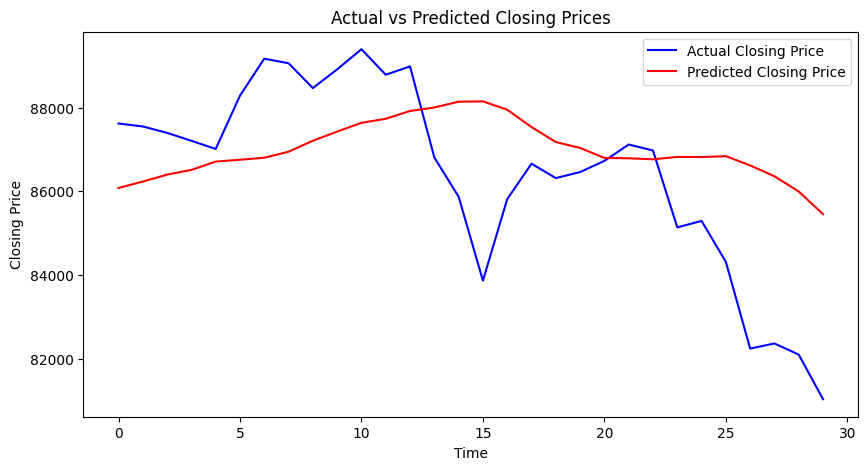

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_3d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features, 1))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_3d_dataset(train_data['Close'].values, time_step, num_features)
X_test, y_test = create_3d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, depth, height, width, channels] for 3D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], num_features, 1, 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], num_features, 1, 1)

# Build the 3D CNN model
model = Sequential()
model.add(Conv3D(filters=64, kernel_size=(2, 1, 1), activation='relu', input_shape=(time_step, num_features, 1, 1)))
model.add(MaxPooling3D(pool_size=(2, 1, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

# Define binary classification based on price increase
true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(y_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary, pred_binary)
precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)
f1 = f1_score(true_binary, pred_binary, zero_division=0)
auc_roc = roc_auc_score(true_binary, y_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Optional: Plotting predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0204
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0032
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0025
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023
Epoch 10/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022
Epoch 11/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020
Epoch 12/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019
Epoch 13/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021
Epoch 14/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 15/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019
Epoch 1

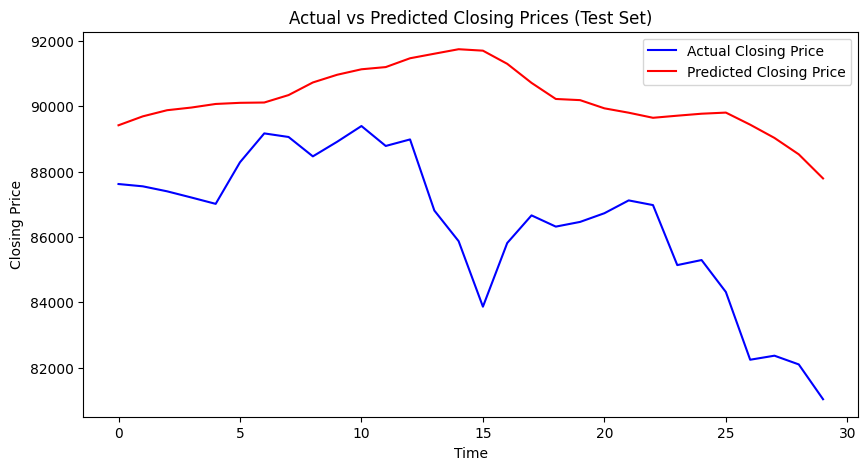

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_3d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features, 1))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X, y = create_3d_dataset(train_data['Close'].values, time_step, num_features)

# Split into train and validation sets (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape input to be [samples, depth, height, width, channels] for 3D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], num_features, 1, 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], num_features, 1, 1)
X_test, y_test = create_3d_dataset(test_data['Close'].values, time_step, num_features)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], num_features, 1, 1)

# Build the 3D CNN model
model = Sequential()
model.add(Conv3D(filters=64, kernel_size=(2, 1, 1), activation='relu', input_shape=(time_step, num_features, 1, 1)))
model.add(MaxPooling3D(pool_size=(2, 1, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Make predictions for validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Inverse transform the predictions for validation
y_val_pred_inverse = scaler.inverse_transform(y_val_pred)
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))

# Calculate regression evaluation metrics for validation set
mae_val = mean_absolute_error(y_val_inverse, y_val_pred_inverse)
mse_val = mean_squared_error(y_val_inverse, y_val_pred_inverse)
rmse_val = np.sqrt(mse_val)
mape_val = mean_absolute_percentage_error(y_val_inverse, y_val_pred_inverse)

# Define binary classification based on price increase for validation
true_binary_val = np.where(y_val_inverse[1:] - y_val_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary_val = np.where(y_val_pred_inverse[:-1] - y_val_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for validation set
accuracy_val = accuracy_score(true_binary_val, pred_binary_val)
precision_val = precision_score(true_binary_val, pred_binary_val, zero_division=0)
recall_val = recall_score(true_binary_val, pred_binary_val, zero_division=0)
f1_val = f1_score(true_binary_val, pred_binary_val, zero_division=0)
auc_roc_val = roc_auc_score(true_binary_val, y_val_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics for validation set
print("Validation Set Metrics:")
print(f"MAE: {mae_val}")
print(f"MSE: {mse_val}")
print(f"RMSE: {rmse_val}")
print(f"MAPE: {mape_val * 100}%")
print(f"Accuracy: {accuracy_val}")
print(f"Precision: {precision_val}")
print(f"Recall: {recall_val}")
print(f"F1-score: {f1_val}")
print(f"AUC-ROC: {auc_roc_val}")

# Inverse transform the predictions for test set
y_test_pred_inverse = scaler.inverse_transform(y_test_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics for test set
mae_test = mean_absolute_error(y_test_inverse, y_test_pred_inverse)
mse_test = mean_squared_error(y_test_inverse, y_test_pred_inverse)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test_inverse, y_test_pred_inverse)

# Define binary classification based on price increase for test set
true_binary_test = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary_test = np.where(y_test_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for test set
accuracy_test = accuracy_score(true_binary_test, pred_binary_test)
precision_test = precision_score(true_binary_test, pred_binary_test, zero_division=0)
recall_test = recall_score(true_binary_test, pred_binary_test, zero_division=0)
f1_test = f1_score(true_binary_test, pred_binary_test, zero_division=0)
auc_roc_test = roc_auc_score(true_binary_test, y_test_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics for test set
print("\nTest Set Metrics:")
print(f"MAE: {mae_test}")
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"MAPE: {mape_test * 100}%")
print(f"Accuracy: {accuracy_test}")
print(f"Precision: {precision_test}")
print(f"Recall: {recall_test}")
print(f"F1-score: {f1_test}")
print(f"AUC-ROC: {auc_roc_test}")

# Optional: Plotting predicted vs actual values for test set
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_test_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices (Test Set)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0152
Epoch 2/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028
Epoch 3/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022
Epoch 4/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023
Epoch 5/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021
Epoch 6/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021
Epoch 7/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018
Epoch 8/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016
Epoch 9/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019
Epoch 10/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 11/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015
Epoch 12/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014
Epoch 13/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 14/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 15/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
MAE: 1746.6675520833335
MSE: 5639949.60480678
RMSE: 2374.8578072816863
MAPE: 2.0654435233044333%
Accuracy: 0.5172413793103449
Precision: 0.4444444444444444
Recall: 0.6666666666666666
F1-score: 0.5333333333333333
AUC-ROC: 0.6029411764705882


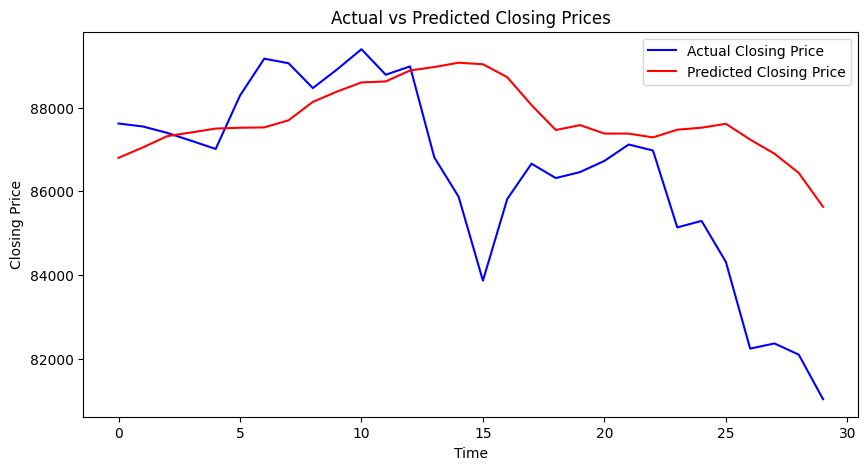

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_3d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features, 1))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X_train, y_train = create_3d_dataset(train_data['Close'].values, time_step, num_features)
X_test, y_test = create_3d_dataset(test_data['Close'].values, time_step, num_features)

# Reshape input to be [samples, depth, height, width, channels] for 3D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], num_features, 1, 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], num_features, 1, 1)

# Build the 3D CNN model
model = Sequential()
model.add(Conv3D(filters=64, kernel_size=(2, 1, 1), activation='relu', input_shape=(time_step, num_features, 1, 1)))
model.add(MaxPooling3D(pool_size=(2, 1, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=1)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_inverse)

# Define binary classification based on price increase
true_binary = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary = np.where(y_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics
accuracy = accuracy_score(true_binary, pred_binary)
precision = precision_score(true_binary, pred_binary, zero_division=0)
recall = recall_score(true_binary, pred_binary, zero_division=0)
f1 = f1_score(true_binary, pred_binary, zero_division=0)
auc_roc = roc_auc_score(true_binary, y_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100}%")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC-ROC: {auc_roc}")

# Optional: Plotting predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0280
Epoch 2/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021
Epoch 3/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024
Epoch 4/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020
Epoch 5/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0020
Epoch 6/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 7/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025
Epoch 8/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020
Epoch 9/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018
Epoch 10/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018
Epoch 11/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017
Epoch 12/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 13/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015
Epoch 14/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016
Epoch 15/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0

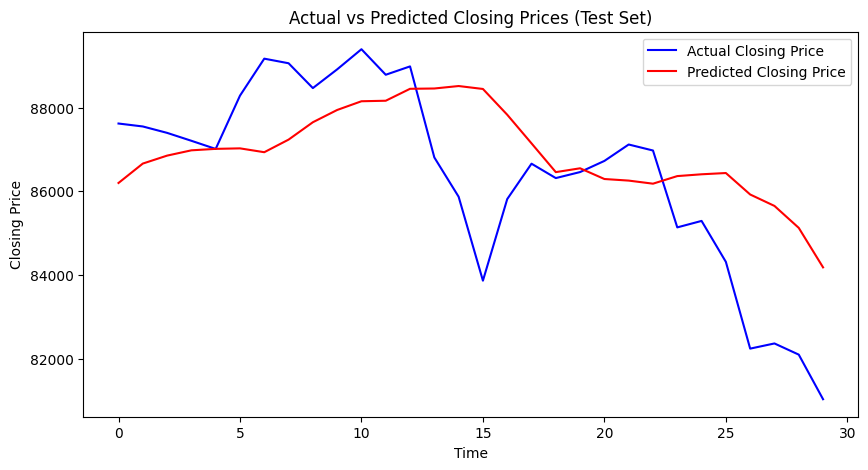

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Convert relevant columns to numeric and drop NaN values
train_data['Close'] = pd.to_numeric(train_data['Close'], errors='coerce')
test_data['Close'] = pd.to_numeric(test_data['Close'], errors='coerce')
train_data.dropna(subset=['Close'], inplace=True)
test_data.dropna(subset=['Close'], inplace=True)

# Normalize the 'Close' column
scaler = MinMaxScaler()
train_data['Close'] = scaler.fit_transform(train_data[['Close']])
test_data['Close'] = scaler.transform(test_data[['Close']])

# Prepare the dataset for the CNN
def create_3d_dataset(data, time_step=1, num_features=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)].reshape(time_step, num_features, 1))
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

# Use a time step of 30 days and 1 feature (Close price)
time_step = 30
num_features = 1
X, y = create_3d_dataset(train_data['Close'].values, time_step, num_features)

# Split into train and validation sets (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape input to be [samples, depth, height, width, channels] for 3D CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], num_features, 1, 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], num_features, 1, 1)
X_test, y_test = create_3d_dataset(test_data['Close'].values, time_step, num_features)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], num_features, 1, 1)

# Build the 3D CNN model
model = Sequential()
model.add(Conv3D(filters=64, kernel_size=(2, 1, 1), activation='relu', input_shape=(time_step, num_features, 1, 1)))
model.add(MaxPooling3D(pool_size=(2, 1, 1)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=1)

# Make predictions for validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Inverse transform the predictions for validation
y_val_pred_inverse = scaler.inverse_transform(y_val_pred)
y_val_inverse = scaler.inverse_transform(y_val.reshape(-1, 1))

# Calculate regression evaluation metrics for validation set
mae_val = mean_absolute_error(y_val_inverse, y_val_pred_inverse)
mse_val = mean_squared_error(y_val_inverse, y_val_pred_inverse)
rmse_val = np.sqrt(mse_val)
mape_val = mean_absolute_percentage_error(y_val_inverse, y_val_pred_inverse)

# Define binary classification based on price increase for validation
true_binary_val = np.where(y_val_inverse[1:] - y_val_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary_val = np.where(y_val_pred_inverse[:-1] - y_val_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for validation set
accuracy_val = accuracy_score(true_binary_val, pred_binary_val)
precision_val = precision_score(true_binary_val, pred_binary_val, zero_division=0)
recall_val = recall_score(true_binary_val, pred_binary_val, zero_division=0)
f1_val = f1_score(true_binary_val, pred_binary_val, zero_division=0)
auc_roc_val = roc_auc_score(true_binary_val, y_val_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics for validation set
print("Validation Set Metrics:")
print(f"MAE: {mae_val}")
print(f"MSE: {mse_val}")
print(f"RMSE: {rmse_val}")
print(f"MAPE: {mape_val * 100}%")
print(f"Accuracy: {accuracy_val}")
print(f"Precision: {precision_val}")
print(f"Recall: {recall_val}")
print(f"F1-score: {f1_val}")
print(f"AUC-ROC: {auc_roc_val}")

# Inverse transform the predictions for test set
y_test_pred_inverse = scaler.inverse_transform(y_test_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate regression evaluation metrics for test set
mae_test = mean_absolute_error(y_test_inverse, y_test_pred_inverse)
mse_test = mean_squared_error(y_test_inverse, y_test_pred_inverse)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test_inverse, y_test_pred_inverse)

# Define binary classification based on price increase for test set
true_binary_test = np.where(y_test_inverse[1:] - y_test_inverse[:-1] > 0, 1, 0)  # 1 if the next closing price is higher
pred_binary_test = np.where(y_test_pred_inverse[:-1] - y_test_inverse[:-1] > 0, 1, 0)

# Calculate classification evaluation metrics for test set
accuracy_test = accuracy_score(true_binary_test, pred_binary_test)
precision_test = precision_score(true_binary_test, pred_binary_test, zero_division=0)
recall_test = recall_score(true_binary_test, pred_binary_test, zero_division=0)
f1_test = f1_score(true_binary_test, pred_binary_test, zero_division=0)
auc_roc_test = roc_auc_score(true_binary_test, y_test_pred_inverse[:-1])  # Use the predicted values for AUC-ROC

# Print evaluation metrics for test set
print("\nTest Set Metrics:")
print(f"MAE: {mae_test}")
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"MAPE: {mape_test * 100}%")
print(f"Accuracy: {accuracy_test}")
print(f"Precision: {precision_test}")
print(f"Recall: {recall_test}")
print(f"F1-score: {f1_test}")
print(f"AUC-ROC: {auc_roc_test}")

# Optional: Plotting predicted vs actual values for test set
plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual Closing Price', color='blue')
plt.plot(y_test_pred_inverse, label='Predicted Closing Price', color='red')
plt.title('Actual vs Predicted Closing Prices (Test Set)')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


# **RNN LSTM XXX**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout


In [ ]:
# Load the training and testing datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Assume the 'Close' column is present in both datasets
train_prices = train_data['Close'].values.reshape(-1, 1)
test_prices = test_data['Close'].values.reshape(-1, 1)


In [ ]:
# Scale the data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_prices = scaler.fit_transform(train_prices)
scaled_test_prices = scaler.transform(test_prices)

# Create a dataset with sequences
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define time step
time_step = 10  # You can adjust this value

# Prepare the training data
X_train, y_train = create_dataset(scaled_train_prices, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)  # Reshape for LSTM

# Prepare the testing data
X_test, y_test = create_dataset(scaled_test_prices, time_step)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)  # Reshape for LSTM


In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, batch_size=1, epochs=10)  # Adjust epochs as necessary


Epoch 1/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0044
Epoch 2/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0014
Epoch 3/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0012
Epoch 4/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 9.6703e-04
Epoch 5/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0010
Epoch 6/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.9148e-04
Epoch 7/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 9.4736e-04
Epoch 8/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 7.9840e-04
Epoch 9/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 8.8838e-04
Epoch 10/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 8.7585e-04


In [ ]:
# Predicting on the test set
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Reverse scaling


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


In [ ]:
# Calculate metrics
mae = mean_absolute_error(test_prices[time_step + 1:], predictions)
mse = mean_squared_error(test_prices[time_step + 1:], predictions)
rmse = np.sqrt(mse)

# Calculate MAPE
mape = np.mean(np.abs((test_prices[time_step + 1:] - predictions) / test_prices[time_step + 1:])) * 100

# Since this is regression, accuracy, precision, recall, F1, and AUC-ROC are not applicable
# But we can check accuracy by thresholding predictions
threshold = np.mean(test_prices)
y_pred_class = (predictions > threshold).astype(int)
y_test_class = (test_prices[time_step + 1:] > threshold).astype(int)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
auc_roc = roc_auc_score(y_test_class, y_pred_class)

# Print all metrics
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print(f'AUC-ROC: {auc_roc}')


MAE: 1964.281065051021
MSE: 6025548.947869411
RMSE: 2454.6993599765756
MAPE: 2.301452835243602%
Accuracy: 0.8163265306122449
Precision: 0.8
Recall: 1.0
F1-score: 0.8888888888888888
AUC-ROC: 0.6538461538461539




---



INCREASING NO. OF EPOCHS

In [ ]:
model.fit(X_train, y_train, batch_size=1, epochs=50)  # Adjust epochs as necessary


Epoch 1/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7.7191e-04
Epoch 2/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 6.7428e-04
Epoch 3/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5.9053e-04
Epoch 4/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 8.4681e-04
Epoch 5/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 8.5100e-04
Epoch 6/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5.3415e-04
Epoch 7/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 8.8454e-04
Epoch 8/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 7.1520e-04
Epoch 9/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5.7427e-04
Epoch 10/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 4.7769e-04
Epoch 11/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 6.1608e-04
Epoch 12/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6.7089e-04
Epoch 13/50
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 7.0153e-04
Epoch 14/50
2603/2603 ━━━━━━━━━━━

In [ ]:
model.fit(X_train, y_train, batch_size=1, epochs=10)  # Adjust epochs as necessary


Epoch 1/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 3.7825e-04
Epoch 2/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5.1623e-04
Epoch 3/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 4.7893e-04
Epoch 4/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - loss: 4.0611e-04
Epoch 5/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 4.6185e-04
Epoch 6/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5.1160e-04
Epoch 7/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 3.9622e-04
Epoch 8/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 3.8141e-04
Epoch 9/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 3.9183e-04
Epoch 10/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 4.3833e-04


In [ ]:
# Predicting on the test set
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Reverse scaling


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [ ]:
# Calculate metrics
mae = mean_absolute_error(test_prices[time_step + 1:], predictions)
mse = mean_squared_error(test_prices[time_step + 1:], predictions)
rmse = np.sqrt(mse)

# Calculate MAPE
mape = np.mean(np.abs((test_prices[time_step + 1:] - predictions) / test_prices[time_step + 1:])) * 100

# Since this is regression, accuracy, precision, recall, F1, and AUC-ROC are not applicable
# But we can check accuracy by thresholding predictions
threshold = np.mean(test_prices)
y_pred_class = (predictions > threshold).astype(int)
y_test_class = (test_prices[time_step + 1:] > threshold).astype(int)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
auc_roc = roc_auc_score(y_test_class, y_pred_class)

# Print all metrics
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print(f'AUC-ROC: {auc_roc}')


MAE: 1627.276951530612
MSE: 3079050.458265465
RMSE: 1754.7223308163218
MAPE: 1.8857678833683555%
Accuracy: 0.5102040816326531
Precision: 0.875
Recall: 0.3888888888888889
F1-score: 0.5384615384615384
AUC-ROC: 0.6175213675213675


# **RNN**

In [ ]:
pip install pandas numpy scikit-learn tensorflow


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0296 - val_loss: 2.7015e-04
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0043 - val_loss: 2.3375e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 1.9251e-04
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019 - val_loss: 1.3074e-04
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 1.2256e-04
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 3.2536e-04
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1665e-04 - val_loss: 5.0855e-04
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 9.2623e-05
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.0422e-04 - val_loss: 1.6519e-04
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.9521e-04 - val_loss: 6.7639e-04
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - val_loss: 8.8867e-

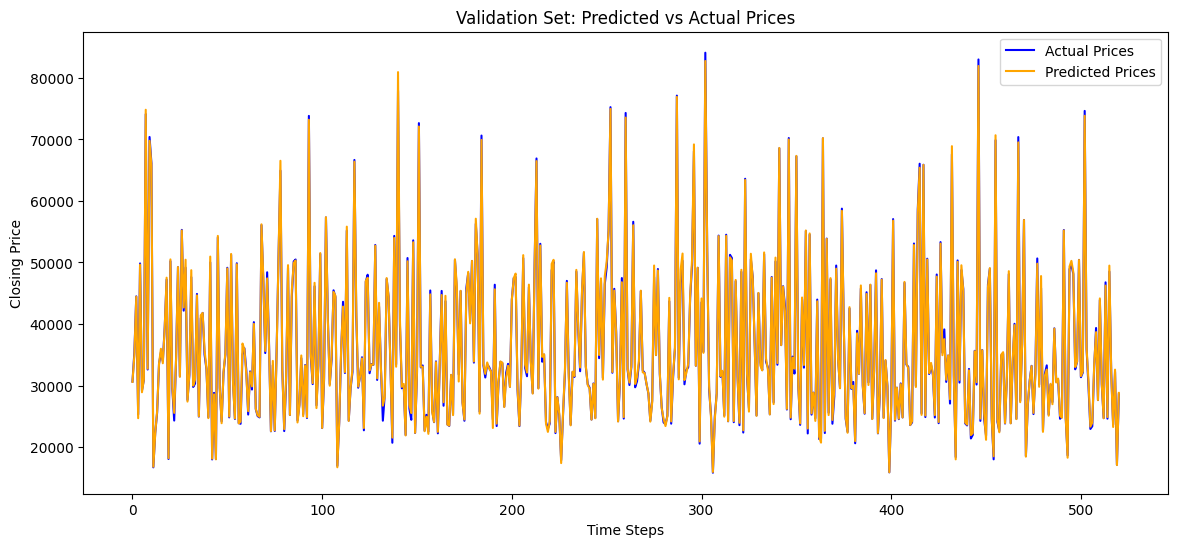

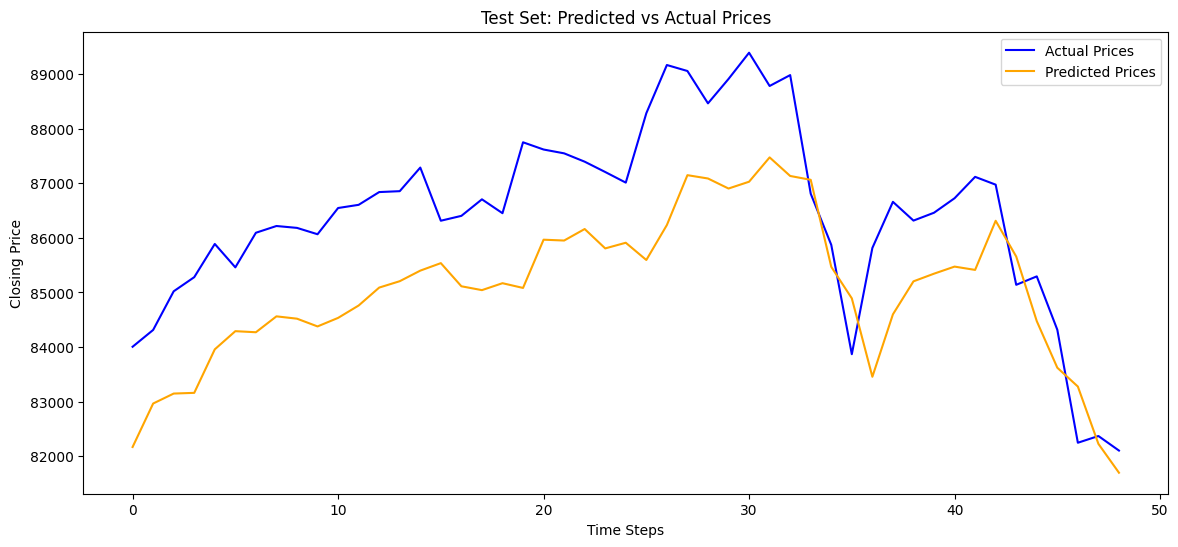

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Load the data
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Select the 'Close' column and convert to numpy array
train_prices = train_data['Close'].values
test_prices = test_data['Close'].values

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_prices_scaled = scaler.fit_transform(train_prices.reshape(-1, 1))
test_prices_scaled = scaler.transform(test_prices.reshape(-1, 1))

# Prepare the dataset for the RNN
def create_dataset(data, time_step=1):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

# Define time step
time_step = 10
X_train, y_train = create_dataset(train_prices_scaled, time_step)
X_test, y_test = create_dataset(test_prices_scaled, time_step)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(50, input_shape=(X_train.shape[1], 1), return_sequences=True))
model.add(Dropout(0.01))  # Dropout layer for regularization
model.add(SimpleRNN(15))  # Second layer with fewer units
model.add(Dropout(0.02))  # Another Dropout layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Implement Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model
model.fit(X_train, y_train, epochs=100, batch_size=32,
          validation_data=(X_val, y_val), callbacks=[early_stopping])

# Predict on validation set
y_val_pred_scaled = model.predict(X_val)
y_val_pred = scaler.inverse_transform(y_val_pred_scaled)
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

# Calculate metrics for validation set
mae_val = mean_absolute_error(y_val_actual, y_val_pred)
mse_val = mean_squared_error(y_val_actual, y_val_pred)
rmse_val = np.sqrt(mse_val)
mape_val = np.mean(np.abs((y_val_actual - y_val_pred) / y_val_actual)) * 100

# Print validation metrics
print(f'Validation MAE: {mae_val}')
print(f'Validation MSE: {mse_val}')
print(f'Validation RMSE: {rmse_val}')
print(f'Validation MAPE: {mape_val}')

# Predict on test set
y_test_pred_scaled = model.predict(X_test)
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics for test set
mae_test = mean_absolute_error(y_test_actual, y_test_pred)
mse_test = mean_squared_error(y_test_actual, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual)) * 100

# Print test metrics
print(f'Test MAE: {mae_test}')
print(f'Test MSE: {mse_test}')
print(f'Test RMSE: {rmse_test}')
print(f'Test MAPE: {mape_test}')

# Binary classification for AUC metrics (example: predicting a price increase)
threshold = 0.01  # Define a threshold for classification
y_val_binary = (y_val_actual[1:] - y_val_actual[:-1]) > (threshold * y_val_actual[:-1])
y_val_pred_binary = (y_val_pred[1:] - y_val_pred[:-1]) > (threshold * y_val_pred[:-1])

# Ensure lengths match
if len(y_val_binary) == len(y_val_pred_binary):
    accuracy_val = accuracy_score(y_val_binary, y_val_pred_binary)
    precision_val = precision_score(y_val_binary, y_val_pred_binary)
    recall_val = recall_score(y_val_binary, y_val_pred_binary)
    f1_val = f1_score(y_val_binary, y_val_pred_binary)
    auc_val = roc_auc_score(y_val_binary, y_val_pred_binary)

    # Print validation classification metrics
    print(f'Validation Accuracy: {accuracy_val}')
    print(f'Validation Precision: {precision_val}')
    print(f'Validation Recall: {recall_val}')
    print(f'Validation F1-score: {f1_val}')
    print(f'Validation AUC-ROC: {auc_val}')
else:
    print("Warning: Length mismatch in binary labels and predictions for validation set.")

# Repeat for the test set
y_test_binary = (y_test_actual[1:] - y_test_actual[:-1]) > (threshold * y_test_actual[:-1])
y_test_pred_binary = (y_test_pred[1:] - y_test_pred[:-1]) > (threshold * y_test_pred[:-1])

# Ensure lengths match for test set metrics
if len(y_test_binary) == len(y_test_pred_binary):
    accuracy_test = accuracy_score(y_test_binary, y_test_pred_binary)
    precision_test = precision_score(y_test_binary, y_test_pred_binary)
    recall_test = recall_score(y_test_binary, y_test_pred_binary)
    f1_test = f1_score(y_test_binary, y_test_pred_binary)
    auc_test = roc_auc_score(y_test_binary, y_test_pred_binary)

    # Print test classification metrics
    print(f'Test Accuracy: {accuracy_test}')
    print(f'Test Precision: {precision_test}')
    print(f'Test Recall: {recall_test}')
    print(f'Test F1-score: {f1_test}')
    print(f'Test AUC-ROC: {auc_test}')
else:
    print("Warning: Length mismatch in binary labels and predictions for test set.")

# Plot predicted vs actual for validation set
plt.figure(figsize=(14, 6))
plt.plot(y_val_actual, label='Actual Prices', color='blue')
plt.plot(y_val_pred, label='Predicted Prices', color='orange')
plt.title('Validation Set: Predicted vs Actual Prices')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

# Plot predicted vs actual for test set
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(y_test_pred, label='Predicted Prices', color='orange')
plt.title('Test Set: Predicted vs Actual Prices')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


# **RNN LSTM**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Load the training and testing datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

# Assume the 'Close' column is present in both datasets
train_prices = train_data['Close'].values.reshape(-1, 1)
test_prices = test_data['Close'].values.reshape(-1, 1)

# Scale the data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_prices = scaler.fit_transform(train_prices)
scaled_test_prices = scaler.transform(test_prices)

# Define function to create sequences
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define time step
time_step = 10  # Adjustable

# Split training data into train and validation sets (80% train, 20% validation)
train_size = int(len(scaled_train_prices) * 0.8)
train_data, val_data = scaled_train_prices[:train_size], scaled_train_prices[train_size:]

# Prepare the training data
X_train, y_train = create_dataset(train_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)  # Reshape for LSTM

# Prepare the validation data
X_val, y_val = create_dataset(val_data, time_step)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)  # Reshape for LSTM

# Prepare the testing data
X_test, y_test = create_dataset(scaled_test_prices, time_step)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)  # Reshape for LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model with validation data
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=1, epochs=10)

# Predicting on the validation set
val_predictions = model.predict(X_val)
val_predictions = scaler.inverse_transform(val_predictions)  # Reverse scaling for validation

# Predicting on the test set
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Reverse scaling for test set

# Calculate metrics for validation set
val_mae = mean_absolute_error(val_data[time_step + 1:], val_predictions)
val_mse = mean_squared_error(val_data[time_step + 1:], val_predictions)
val_rmse = np.sqrt(val_mse)
val_mape = np.mean(np.abs((val_data[time_step + 1:] - val_predictions) / val_data[time_step + 1:])) * 100

# Accuracy metrics for validation set based on thresholding
val_threshold = np.mean(val_data)
val_pred_class = (val_predictions > val_threshold).astype(int)
val_true_class = (val_data[time_step + 1:] > val_threshold).astype(int)

val_accuracy = accuracy_score(val_true_class, val_pred_class)
val_precision = precision_score(val_true_class, val_pred_class)
val_recall = recall_score(val_true_class, val_pred_class)
val_f1 = f1_score(val_true_class, val_pred_class)
val_auc_roc = roc_auc_score(val_true_class, val_pred_class)

# Calculate metrics for test set
mae = mean_absolute_error(test_prices[time_step + 1:], predictions)
mse = mean_squared_error(test_prices[time_step + 1:], predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_prices[time_step + 1:] - predictions) / test_prices[time_step + 1:])) * 100

# Accuracy metrics for test set based on thresholding
threshold = np.mean(test_prices)
y_pred_class = (predictions > threshold).astype(int)
y_test_class = (test_prices[time_step + 1:] > threshold).astype(int)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
auc_roc = roc_auc_score(y_test_class, y_pred_class)

# Print metrics for validation and test sets
print("\n--- Validation Metrics ---")
print(f'MAE: {val_mae}')
print(f'MSE: {val_mse}')
print(f'RMSE: {val_rmse}')
print(f'MAPE: {val_mape}%')
print(f'Accuracy: {val_accuracy}')
print(f'Precision: {val_precision}')
print(f'Recall: {val_recall}')
print(f'F1-score: {val_f1}')
print(f'AUC-ROC: {val_auc_roc}')

print("\n--- Test Metrics ---")
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print(f'AUC-ROC: {auc_roc}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0019 - val_loss: 9.1648e-04
Epoch 2/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5.2882e-04 - val_loss: 0.0044
Epoch 3/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5.2550e-04 - val_loss: 0.0013
Epoch 4/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 4.8101e-04 - val_loss: 3.6872e-04
Epoch 5/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 4.3020e-04 - val_loss: 0.0054
Epoch 6/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4.4962e-04 - val_loss: 8.7642e-04
Epoch 7/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 3.6828e-04 - val_loss: 0.0012
Epoch 8/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 3.9779e-04 - val_loss: 8.0017e-04
Epoch 9/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 3.0127e-04 - val_loss: 3.7253e-04
Epoch 10/10
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 3.0612e-04 - val_loss: 9.9148e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
2

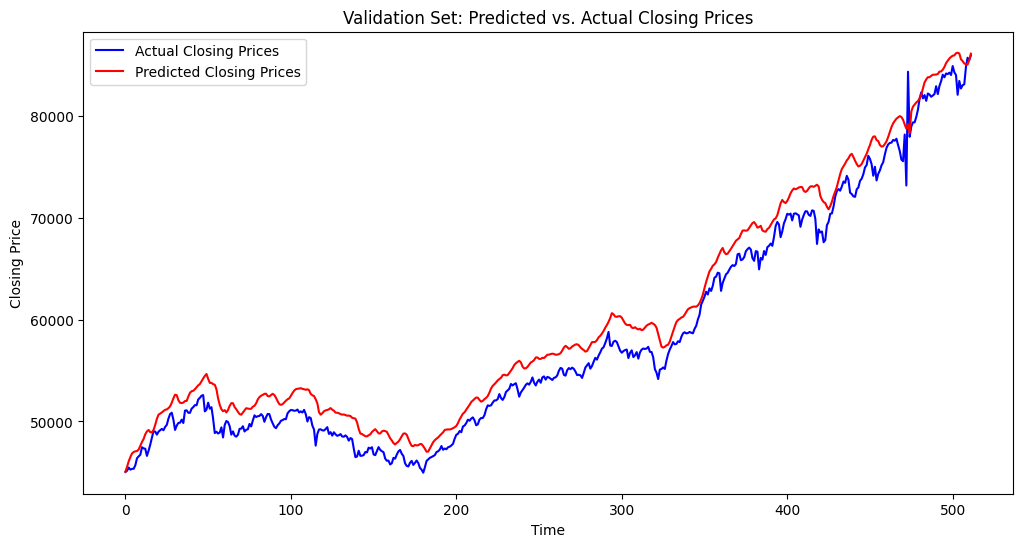

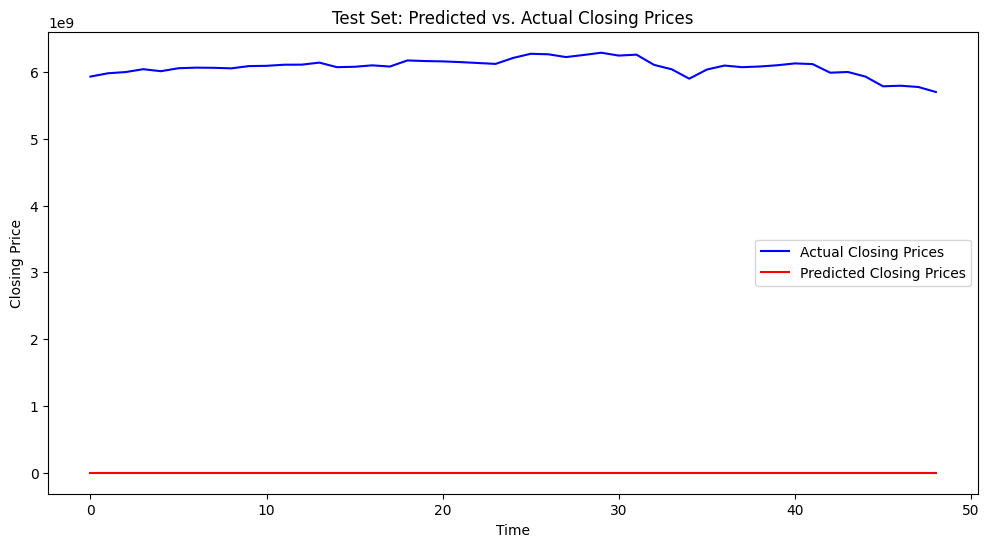

In [ ]:
import matplotlib.pyplot as plt

# Plot for Validation Set: Predicted vs. Actual Closing Prices
plt.figure(figsize=(12, 6))
plt.plot(range(len(val_data[time_step + 1:])), scaler.inverse_transform(val_data[time_step + 1:]), label="Actual Closing Prices", color='blue')
plt.plot(range(len(val_predictions)), val_predictions, label="Predicted Closing Prices", color='red')
plt.title("Validation Set: Predicted vs. Actual Closing Prices")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

# Plot for Test Set: Predicted vs. Actual Closing Prices
plt.figure(figsize=(12, 6))
plt.plot(range(len(test_prices[time_step + 1:])), scaler.inverse_transform(test_prices[time_step + 1:]), label="Actual Closing Prices", color='blue')
plt.plot(range(len(predictions)), predictions, label="Predicted Closing Prices", color='red')
plt.title("Test Set: Predicted vs. Actual Closing Prices")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.show()
